# FAALProt Heterogeneity Analysis

In [1]:

# -*- coding: utf-8 -*-
from __future__ import annotations

import os, sys, json, shutil, random, warnings, argparse, subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional deps
try:
    from Bio import SeqIO
    HAS_BIO = True
except Exception:
    HAS_BIO = False

# UMAP (optional)
try:
    import umap
    HAS_UMAP = True
except Exception:
    try:
        from umap import UMAP as _UMAP
        class umap:
            UMAP = _UMAP
        HAS_UMAP = True
    except Exception:
        HAS_UMAP = False

# t-SNE
from sklearn.manifold import TSNE

# W2V (optional Part B)
try:
    from gensim.models import Word2Vec
    HAS_GENSIM = True
except Exception:
    HAS_GENSIM = False

# Dendrogram + distances
try:
    from scipy.cluster.hierarchy import linkage, dendrogram
    from scipy.spatial.distance import squareform
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

try:
    from sklearn.metrics import pairwise_distances
    HAS_SK_PWD = True
except Exception:
    HAS_SK_PWD = False

RANDOM_STATE = 42
FIXED_CUTOFFS = [10,20,30,40,50,60,70,80,90]
DOMAIN_TOKS = {'bacteria','archaea','eukaryota','eukarya','viruses','virus','viroids'}

# IO defaults
FASTA_PATH = Path('FAAL_NR_MIBIG_LEGE_FFT_NS_2_raw_data.fasta')
TABLE_S2_PATH = Path('Table_S2.tsv')
OUTDIR = Path('runs/FAALProt_Heterogeneity_v6')
OUTDIR.mkdir(parents=True, exist_ok=True)

print('OUTDIR:', OUTDIR.resolve())
print('FASTA exists:', FASTA_PATH.exists())
print('Table_S2 exists:', TABLE_S2_PATH.exists())


/home/mattoslmp/anaconda3/envs/fall/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OUTDIR: /home/mattoslmp/FAALPred/Resposta_protein_science/runs/FAALProt_Heterogeneity_v6
FASTA exists: True
Table_S2 exists: True


In [2]:

def _is_exec(p: str) -> bool:
    try:
        return p and os.path.isfile(p) and os.access(p, os.X_OK)
    except Exception:
        return False

def _tokens_from_whereis(name: str) -> List[str]:
    try:
        out = subprocess.run(['whereis', name], capture_output=True, text=True, check=False)
        toks = out.stdout.strip().split()
        return [t for t in toks[1:] if os.path.isabs(t)]
    except Exception:
        return []

def find_executable(name: str, user_hint: Optional[str]=None, extra_candidates: Optional[List[str]]=None) -> Optional[str]:
    env_hint = os.environ.get(f"{name.upper()}_BIN") or os.environ.get(f"{name.lower()}_bin")
    for cand in [user_hint, env_hint]:
        if cand and _is_exec(cand):
            print(f"[bin] Using explicit {name}: {cand}")
            return cand
    w = shutil.which(name)
    if _is_exec(w or ""):
        print(f"[bin] Found {name} in PATH: {w}")
        return w
    cp = os.environ.get('CONDA_PREFIX')
    if cp:
        cand = os.path.join(cp, 'bin', name)
        if _is_exec(cand):
            print(f"[bin] Found {name} in CONDA_PREFIX: {cand}")
            return cand
    for cand in (extra_candidates or []):
        if _is_exec(cand):
            print(f"[bin] Found {name} in candidates: {cand}")
            return cand
    for cand in _tokens_from_whereis(name):
        if _is_exec(cand):
            print(f"[bin] Found {name} via whereis: {cand}")
            return cand
    print(f"[bin][WARN] Could not locate '{name}'.")
    return None


In [3]:

def ensure_outdir(path: str) -> None:
    os.makedirs(path, exist_ok=True)

def _save_multiformat(out_base: str) -> Dict[str, str]:
    out = {}
    base = os.path.splitext(out_base)[0]
    svg = base + '.svg'
    png = base + '.png'
    tif = base + '.tiff'
    plt.tight_layout()
    plt.savefig(svg, bbox_inches='tight')
    plt.savefig(png, dpi=900, bbox_inches='tight')
    plt.savefig(tif, dpi=900, bbox_inches='tight')
    plt.show()
    plt.close()
    out['svg'] = svg; out['png'] = png; out['tiff'] = tif
    print('[saved]', os.path.basename(svg), os.path.basename(png), os.path.basename(tif))
    return out


In [4]:

def read_fasta_minimal(fasta_path: str) -> pd.DataFrame:
    ids, seqs = [], []
    with open(fasta_path, 'r', encoding='utf-8') as f:
        cur, buf = None, []
        for line in f:
            line=line.strip()
            if not line: continue
            if line.startswith('>'):
                if cur is not None:
                    seqs.append(''.join(buf)); buf=[]
                cur = line[1:].split()[0]
                ids.append(cur)
            else:
                buf.append(line)
        if cur is not None:
            seqs.append(''.join(buf))
    return pd.DataFrame({'sequence_id': ids, 'sequence': seqs})

def write_fasta(df: pd.DataFrame, out_fa: str) -> None:
    with open(out_fa, 'w', encoding='utf-8') as f:
        for _, r in df.iterrows():
            sid = str(r['sequence_id'])
            seq = str(r['sequence'])
            f.write(">" + sid + "\n" + seq + "\n")


In [5]:

# Phylum normalization and metadata join
def normalize_phylum_name(s: Optional[str]) -> str:
    if not isinstance(s, str) or not s.strip():
        return 'Unknown'
    t = s.strip()
    if t.lower() == 'actinobacteria':
        return 'Actinomycetota'
    return t

def _extract_phylum_from_lineage(lineage: str) -> str:
    if not isinstance(lineage, str) or not lineage.strip():
        return 'Unknown'
    toks = [t.strip() for t in lineage.split(';') if t.strip()]
    if len(toks) >= 2:
        ph = toks[1]
        return normalize_phylum_name(ph) if ph and ph.lower() not in DOMAIN_TOKS else 'Unknown'
    if len(toks) == 1:
        first = toks[0]
        if first.lower() in DOMAIN_TOKS:
            return 'Unknown'
        return normalize_phylum_name(first)
    return 'Unknown'

def read_table_s2(table_path: Optional[str]) -> Optional[pd.DataFrame]:
    if not table_path or not os.path.exists(table_path):
        return None
    ext = Path(table_path).suffix.lower()
    if ext == '.tsv':
        df = pd.read_csv(table_path, sep='\t', dtype=str, engine='python')
    else:
        try:
            df = pd.read_csv(table_path, sep=None, dtype=str, engine='python')
        except Exception:
            df = pd.read_csv(table_path, dtype=str)
    cols = {c.lower(): c for c in df.columns}
    acc = cols.get('protein accession') or cols.get('protein_accession') or cols.get('sequence id') or cols.get('sequence_id')
    lin = cols.get('lineage')
    if acc is not None and lin is not None:
        tmp = df[[acc, lin]].copy().rename(columns={acc:'sequence_id', lin:'Lineage'})
        tmp['phylum'] = tmp['Lineage'].apply(_extract_phylum_from_lineage).apply(normalize_phylum_name)
        return tmp[['sequence_id','phylum']].dropna().drop_duplicates()
    for c in ['phylum','Phylum','tax_phylum','taxonomy_phylum']:
        if c in df.columns:
            if 'sequence_id' in df.columns:
                tmp = df[['sequence_id',c]].copy()
            elif acc is not None:
                tmp = df[[acc,c]].copy().rename(columns={acc:'sequence_id'})
            else:
                continue
            tmp = tmp.rename(columns={c:'phylum'})
            tmp['phylum'] = tmp['phylum'].apply(lambda s: 'Unknown' if isinstance(s, str) and s.lower() in DOMAIN_TOKS else normalize_phylum_name(s))
            return tmp.dropna().drop_duplicates()
    return None

def merge_phylum_info(seqs_df: pd.DataFrame, meta_df: Optional[pd.DataFrame]) -> pd.DataFrame:
    out = seqs_df.copy()
    if meta_df is None:
        out['phylum'] = 'Unknown'
        return out
    out = out.merge(meta_df[['sequence_id','phylum']].drop_duplicates(), on='sequence_id', how='left')
    out['phylum'] = out['phylum'].fillna('Unknown').apply(normalize_phylum_name)
    return out


In [6]:

from matplotlib import cm, colors as mpl_colors

def _rgba_tuple(c):
    if isinstance(c, tuple) and len(c) in (3,4):
        if len(c)==3: return (c[0],c[1],c[2],1.0)
        return c
    try:
        r,g,b,a = mpl_colors.to_rgba(c)
        return (r,g,b,a)
    except Exception:
        return (0.5,0.5,0.5,1.0)

def _distinct_palette(n: int):
    if n <= 0:
        return []
    base = []
    for name in ['tab20','tab20b','tab20c']:
        cmap = cm.get_cmap(name)
        base += list(cmap.colors) if hasattr(cmap, 'colors') else [cmap(i) for i in np.linspace(0,1,20)]
    base = [ _rgba_tuple(c) for c in base ]
    if n <= len(base):
        return base[:n]
    extra = []
    for i in range(n - len(base)):
        h = (i * 0.61803398875) % 1.0  # golden ratio
        s = 0.88
        v = 0.92 if (i % 2 == 0) else 0.78
        r,g,b = mpl_colors.hsv_to_rgb((h,s,v))
        extra.append((r,g,b,1.0))
    return base + extra

def _is_excluded_phylum(s: Optional[str]) -> bool:
    if not isinstance(s, str): return True
    sl = s.strip().lower()
    if sl == '': return True
    return ('unknown' in sl) or ('uncultured' in sl) or ('uncultivated' in sl) or ('uncultived' in sl)

def build_global_phylum_palette(seqs_df: pd.DataFrame) -> Dict[str, tuple]:
    uniq = sorted({normalize_phylum_name(p) for p in seqs_df['phylum'].astype(str).unique() if not _is_excluded_phylum(p)})
    cols = _distinct_palette(len(uniq))
    return {p: cols[i] for i,p in enumerate(uniq)}


In [7]:

@dataclass
class SubsetParams:
    size: Optional[int] = None
    fraction: Optional[float] = None
    seed: int = 42

def apply_subset_random(seqs_df: pd.DataFrame, params: SubsetParams) -> Tuple[pd.DataFrame, str]:
    n = len(seqs_df)
    if params.size is None and params.fraction is None:
        return seqs_df.copy(), 'full'
    rng = random.Random(params.seed)
    if params.size is not None:
        k = min(n, int(params.size))
    else:
        k = max(1, min(n, int(round(n*float(params.fraction)))))
    idx = list(range(n)); rng.shuffle(idx)
    take = sorted(idx[:k])
    out = seqs_df.iloc[take].copy()
    label = f"size_{k}" if params.size is not None else f"frac_{params.fraction:.3f}".replace('.','p')
    return out, label


In [8]:

def run_mafft_msa(seqs_df: pd.DataFrame, run_dir: str, mafft_bin: str, mafft_opts: Optional[List[str]] = None) -> str:
    ensure_outdir(run_dir)
    fa_in  = os.path.join(run_dir, 'sequences_for_mafft.fasta')
    fa_out = os.path.join(run_dir, 'sequences_mafft_aligned.fasta')
    write_fasta(seqs_df, fa_in)
    if mafft_opts is None:
        mafft_opts = ['--auto']
    cmd = [mafft_bin] + list(mafft_opts) + [fa_in]
    print('[mafft]', ' '.join(cmd))
    with open(fa_out, 'w', encoding='utf-8') as fout:
        proc = subprocess.run(cmd, stdout=fout, stderr=subprocess.PIPE, text=True)
    if proc.returncode != 0:
        raise RuntimeError(f"MAFFT failed:\n{proc.stderr}")
    return fa_out

def read_aligned_fasta_to_array(fa_aligned: str) -> Tuple[List[str], np.ndarray]:
    ids, seqs = [], []
    if HAS_BIO:
        for rec in SeqIO.parse(fa_aligned, 'fasta'):
            ids.append(str(rec.id)); seqs.append(str(rec.seq))
    else:
        with open(fa_aligned, 'r', encoding='utf-8') as f:
            cur, buf = None, []
            for line in f:
                line=line.strip()
                if not line: continue
                if line.startswith('>'):
                    if cur is not None:
                        seqs.append(''.join(buf)); buf=[]
                    cur = line[1:].split()[0]; ids.append(cur)
                else:
                    buf.append(line)
            if cur is not None:
                seqs.append(''.join(buf))
    arr = np.array([list(s) for s in seqs], dtype='<U1')
    return ids, arr

def msa_identities_stream(ids: List[str], arr: np.ndarray, out_csv: str, sample_sizes: List[int]) -> Dict[int, pd.DataFrame]:
    n = len(ids); total = n*(n-1)//2
    ensure_outdir(os.path.dirname(out_csv))
    with open(out_csv, 'w', encoding='utf-8') as f:
        f.write('seq_i,seq_j,identity_percent\n')
        strides = {s: max(1, total//int(s)) for s in sample_sizes}
        buffers = {s: [] for s in sample_sizes}
        k = 0
        for i in range(n):
            Ai = arr[i]
            for j in range(i+1, n):
                Aj = arr[j]
                both = (Ai != '-') & (Aj != '-')
                denom = int(both.sum())
                idp = 0.0 if denom == 0 else 100.0 * int(((Ai == Aj) & both).sum())/denom
                f.write(f"{ids[i]},{ids[j]},{idp:.6f}\n")
                for s in sample_sizes:
                    if (k % strides[s]) == 0:
                        buffers[s].append((ids[i], ids[j], idp))
                k += 1
    out = {}
    for s, buf in buffers.items():
        df = pd.DataFrame(buf, columns=['seq_i','seq_j','identity_percent'])
        df.to_csv(os.path.join(os.path.dirname(out_csv), f"pairs_sample_{s}.csv"), index=False)
        out[s] = df
    return out


In [9]:

def mmseqs_prepare_db(mmseqs_bin: str, fasta_path: str, run_dir: str) -> Tuple[str, str]:
    db = os.path.join(run_dir, 'mmseqs_db')
    tmp = os.path.join(run_dir, 'mmseqs_tmp')
    ensure_outdir(tmp)
    subprocess.run([mmseqs_bin,'createdb',fasta_path,db], check=True)
    subprocess.run([mmseqs_bin,'createindex',db,tmp], check=True)
    return db, tmp

def mmseqs_cluster_for_cutoff(mmseqs_bin: str, db: str, tmp: str, run_dir: str, cutoff: float, extra_opts: Optional[List[str]] = None) -> str:
    outbase = os.path.join(run_dir, f"mmseqs_clu_{int(cutoff)}")
    out = outbase
    min_id = float(cutoff)/100.0
    cmd = [mmseqs_bin,'cluster', db, out, tmp, '--min-seq-id', str(min_id)]
    if extra_opts is None:
        extra_opts = ['--cov-mode','0']
    cmd += extra_opts
    print('[mmseqs]', ' '.join(cmd))
    try:
        subprocess.run(cmd, check=True, capture_output=True, text=True)
        tsv = outbase + '.tsv'
        cmd_tsv = [mmseqs_bin,'createtsv', db, db, out, tsv]
        subprocess.run(cmd_tsv, check=True, capture_output=True, text=True)
        return tsv
    except subprocess.CalledProcessError as e:
        print('[mmseqs][cluster][error]:', (e.stderr or e.stdout or str(e)))
        fasta_in = os.path.join(run_dir, 'sequences_for_mmseqs.fasta')
        easy_dir = os.path.join(run_dir, f"easy_{int(cutoff)}"); ensure_outdir(easy_dir)
        easy_cmd = [mmseqs_bin,'easy-cluster', fasta_in, easy_dir, tmp, '--min-seq-id', str(min_id)] + extra_opts
        subprocess.run(easy_cmd, check=True, capture_output=True, text=True)
        for cand in [os.path.join(easy_dir, 'cluster.tsv'),
                     easy_dir + '_cluster.tsv',
                     os.path.join(easy_dir, 'easy_cluster.tsv')]:
            if os.path.exists(cand):
                return cand
        return outbase + '.tsv'

def parse_mmseqs_tsv_to_clusters(tsv_path: str, cutoff: float) -> pd.DataFrame:
    rows = []
    with open(tsv_path, 'r', encoding='utf-8') as f:
        for line in f:
            line=line.strip()
            if not line or line.startswith('#'): continue
            parts = line.split('\t')
            if len(parts) < 2: continue
            rep, mem = parts[0], parts[1]
            rows.append({'sequence_id': mem, 'cutoff': float(cutoff), 'cluster_id': rep})
    df = pd.DataFrame(rows)
    if df.empty: return df
    df['cluster_size'] = df.groupby(['cutoff','cluster_id'])['sequence_id'].transform('size')
    return df

def generate_clusters_with_mmseqs(mmseqs_bin: str, seqs_df: pd.DataFrame, run_dir: str, cutoffs: List[int], extra_opts: Optional[List[str]] = None) -> pd.DataFrame:
    fasta_in = os.path.join(run_dir, 'sequences_for_mmseqs.fasta')
    write_fasta(seqs_df, fasta_in)
    db, tmp = mmseqs_prepare_db(mmseqs_bin, fasta_in, run_dir)
    parts = []
    for c in cutoffs:
        tsv = mmseqs_cluster_for_cutoff(mmseqs_bin, db, tmp, run_dir, c, extra_opts=extra_opts)
        parts.append(parse_mmseqs_tsv_to_clusters(tsv, c))
    out = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=['sequence_id','cutoff','cluster_id','cluster_size'])
    out_csv = os.path.join(run_dir, 'clusters_multi_threshold.csv')
    out.to_csv(out_csv, index=False)
    print('[ok] clusters ->', out_csv)
    return out


In [10]:

def _canonicalize_pairs(df_pairs: pd.DataFrame) -> pd.DataFrame:
    a = df_pairs[['seq_i','seq_j']].min(axis=1)
    b = df_pairs[['seq_i','seq_j']].max(axis=1)
    out = df_pairs.copy()
    out['a'] = a; out['b'] = b
    return out.drop(columns=['seq_i','seq_j']).drop_duplicates(['a','b'])

def intra_cluster_pairs_for_cutoff(pairs_df: pd.DataFrame, clusters_df: pd.DataFrame, cutoff: int) -> pd.DataFrame:
    if pairs_df.empty or clusters_df.empty:
        return pd.DataFrame(columns=['a','b','identity_percent','cluster_id'])
    P = _canonicalize_pairs(pairs_df)
    mem = clusters_df[clusters_df['cutoff']==cutoff][['sequence_id','cluster_id']].drop_duplicates()
    m = (
        P.merge(mem.rename(columns={'sequence_id':'a'}), on='a', how='inner')
         .merge(mem.rename(columns={'sequence_id':'b','cluster_id':'cluster_id_b'}), on='b', how='inner')
    )
    m = m[m['cluster_id']==m['cluster_id_b']]
    return m[['a','b','identity_percent','cluster_id']]

def build_dissimilarity_matrix_from_pairs(ids: List[str], pairs_df_sample: pd.DataFrame) -> np.ndarray:
    n = len(ids)
    D = np.ones((n,n), dtype=float); np.fill_diagonal(D, 0.0)
    index = {sid:i for i,sid in enumerate(ids)}
    for _, row in pairs_df_sample.iterrows():
        a, b, idp = row['seq_i'], row['seq_j'], float(row['identity_percent'])
        if a in index and b in index:
            i, j = index[a], index[b]
            d = 1.0 - (idp/100.0)
            if d < D[i,j]: D[i,j] = D[j,i] = d
    return D


In [11]:

from matplotlib import colors as mpl_colors

def plot_umap_from_pairs_sample(pairs_df_sample: pd.DataFrame, seqs_df: pd.DataFrame, outdir: str, palette: Optional[Dict[str, tuple]]=None) -> Dict[str,str]:
    ensure_outdir(outdir)
    if pairs_df_sample is None or pairs_df_sample.empty or not HAS_UMAP:
        warnings.warn('Empty pairs sample or UMAP unavailable — skipped UMAP.'); return {}
    ids = pd.unique(pd.concat([pairs_df_sample['seq_i'], pairs_df_sample['seq_j']], ignore_index=True)).tolist()
    ids = [sid for sid in ids if sid in set(seqs_df['sequence_id'].tolist())]
    if len(ids) < 2:
        warnings.warn('Not enough unique IDs for UMAP.'); return {}
    ph_map = seqs_df.set_index('sequence_id')['phylum'].to_dict()
    ids_filt = [sid for sid in ids if not _is_excluded_phylum(ph_map.get(sid, 'Unknown'))]
    if len(ids_filt) < 2:
        warnings.warn('No eligible phyla to plot after filtering.'); return {}
    D = build_dissimilarity_matrix_from_pairs(ids_filt, pairs_df_sample)
    reducer = umap.UMAP(metric='precomputed', random_state=RANDOM_STATE, n_neighbors=20, min_dist=0.05)
    emb = reducer.fit_transform(D)
    phyla = sorted({ph_map.get(sid) for sid in ids_filt})
    if palette is None:
        colors = _distinct_palette(len(phyla)) if len(phyla)>0 else [(0,0,0,1)]
        color_map = {p: colors[i] for i,p in enumerate(phyla)}
    else:
        color_map = {p: palette.get(p, (0.6,0.6,0.6,1.0)) for p in phyla}
    point_colors = [color_map.get(ph_map.get(sid), (0.5,0.5,0.5,1)) for sid in ids_filt]
    plt.figure(figsize=(13.0, 13.0))
    ax = plt.gca()
    ax.scatter(emb[:,0], emb[:,1], c=point_colors, s=18, alpha=0.95, linewidths=0)
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.set_aspect('equal', adjustable='box')
    from matplotlib.lines import Line2D
    uniq = sorted(phyla)
    handles = [Line2D([0],[0], marker='o', color='w', label=p, markerfacecolor=color_map[p], markersize=6) for p in uniq]
    ax.legend(handles=handles, bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=min(6, max(1,len(uniq))))
    out = os.path.join(outdir, '04_umap_dissimilarity_by_phylum')
    return _save_multiformat(out)

def plot_dendrogram_from_pairs_sample(pairs_df_sample: pd.DataFrame, seqs_df: pd.DataFrame, outdir: str, palette: Optional[Dict[str, tuple]]=None, method: str='average', max_leaves: Optional[int]=None) -> Dict[str,str]:
    ensure_outdir(outdir)
    if not HAS_SCIPY:
        warnings.warn('scipy not available — skipping dendrogram.'); return {}
    if pairs_df_sample is None or pairs_df_sample.empty:
        warnings.warn('Empty pairs sample — skipped dendrogram.'); return {}
    ph_map = seqs_df.set_index('sequence_id')['phylum'].to_dict()
    ids = pd.unique(pd.concat([pairs_df_sample['seq_i'], pairs_df_sample['seq_j']], ignore_index=True)).tolist()
    ids = [sid for sid in ids if sid in set(seqs_df['sequence_id'].tolist())]
    ids = [sid for sid in ids if not _is_excluded_phylum(ph_map.get(sid, 'Unknown'))]
    if len(ids) < 3:
        warnings.warn('Not enough eligible IDs for dendrogram.'); return {}
    if max_leaves is not None and len(ids) > max_leaves:
        rng = np.random.default_rng(RANDOM_STATE)
        ids = list(sorted(rng.choice(ids, size=max_leaves, replace=False)))
    D = build_dissimilarity_matrix_from_pairs(ids, pairs_df_sample)
    condensed = squareform(D, checks=False)
    Z = linkage(condensed, method=method)
    n = len(ids)
    leaf_phyla = {i: {ph_map.get(ids[i], 'Unknown')} for i in range(n)}
    node_sets = dict(leaf_phyla)
    for idx, (a,b,_,_) in enumerate(Z):
        a = int(a); b = int(b); node = n + idx
        node_sets[node] = node_sets.get(a, set()) | node_sets.get(b, set())
    if palette is None:
        uniq = sorted({ph_map.get(sid, 'Unknown') for sid in ids if not _is_excluded_phylum(ph_map.get(sid,'Unknown'))})
        pal_list = _distinct_palette(len(uniq))
        palette = {p: pal_list[i] for i,p in enumerate(uniq)}
    hexmap = {k: mpl_colors.to_hex((v[0],v[1],v[2],1.0), keep_alpha=False) for k,v in palette.items()}
    def link_color_func(k):
        s = node_sets.get(int(k), set())
        if len(s) == 1:
            ph = next(iter(s))
            return hexmap.get(ph, '#999999')
        return '#B0B0B0'
    plt.figure(figsize=(14, 6.5))
    dendrogram(Z, no_labels=True, color_threshold=0, above_threshold_color='#B0B0B0', link_color_func=link_color_func)
    plt.xlabel('Sequences (leaves)')
    plt.ylabel('Distance (1 - identity)')
    from matplotlib.lines import Line2D
    uniq_ph = sorted(list({ph_map.get(sid, 'Unknown') for sid in ids if not _is_excluded_phylum(ph_map.get(sid,'Unknown'))}))
    handles = [Line2D([0],[0], color=hexmap.get(p,'#999999'), lw=2, label=p) for p in uniq_ph]
    plt.legend(handles=handles, bbox_to_anchor=(0.5, -0.18), loc='upper center', ncol=min(6, max(1, len(handles))))
    out = os.path.join(outdir, '03_dendrogram_branches_by_phylum')
    return _save_multiformat(out)


In [12]:

# W2V Part B + reductions + dendrogram from W2V means
@dataclass
class W2VParams:
    k: int = 3
    vector_size: int = 200
    window: int = 5
    min_count: int = 1
    sg: int = 1
    epochs: int = 20
    workers: int = 4

def tokens_from_msa(ids: List[str], arr: np.ndarray, k: int, drop_gaps: bool=True) -> Dict[str, List[str]]:
    toks = {}
    for i, sid in enumerate(ids):
        s = ''.join(arr[i])
        if drop_gaps: s = s.replace('-', '')
        if len(s) >= k:
            toks[sid] = [s[j:j+k] for j in range(0, len(s)-k+1)]
        else:
            toks[sid] = ['PAD']
    return toks

def train_w2v(tokens_by_seq: Dict[str, List[str]], p: W2VParams):
    if not HAS_GENSIM:
        warnings.warn('gensim not available — skipping Part B.'); return None
    model = Word2Vec(
        sentences=list(tokens_by_seq.values()),
        vector_size=p.vector_size, window=p.window,
        min_count=p.min_count, sg=p.sg, workers=p.workers,
        epochs=p.epochs, seed=RANDOM_STATE
    )
    return model

def sentence_and_mean_embeddings(tokens_by_seq: Dict[str, List[str]], model, run_dir: str) -> pd.DataFrame:
    sent_dir = os.path.join(run_dir, 'w2v_sentences'); ensure_outdir(sent_dir)
    rows = []
    for sid, toks in tokens_by_seq.items():
        vecs = [model.wv[t] for t in toks if t in model.wv]
        if len(vecs)==0:
            emb = np.zeros((1, model.vector_size), dtype=float)
        else:
            emb = np.stack(vecs, axis=0)
        np.save(os.path.join(sent_dir, f'{sid}.npy'), emb)
        mean_vec = emb.mean(axis=0)
        row = {'sequence_id': sid}
        for i, v in enumerate(mean_vec):
            row[f'f{i:03d}'] = float(v)
        rows.append(row)
    df = pd.DataFrame(rows)
    pd.DataFrame({'sequence_id': list(tokens_by_seq.keys()),
                  'num_kmers': [len(tokens_by_seq[s]) for s in tokens_by_seq.keys()]}).to_csv(
        os.path.join(run_dir,'w2v_sentence_index.csv'), index=False)
    return df

def cosine_vs_identity_plots(pairs_df_sample: pd.DataFrame, emb_df: pd.DataFrame, seqs_df: pd.DataFrame, outdir: str) -> Tuple[Dict[str,str], Dict[str,str]]:
    ensure_outdir(outdir)
    feat_cols = [c for c in emb_df.columns if c.startswith('f')]
    if not feat_cols:
        warnings.warn('No W2V features — skipping cosine vs identity.'); return {}, {}
    M = emb_df.set_index('sequence_id')[feat_cols]
    ph = seqs_df.set_index('sequence_id')['phylum'].to_dict()
    rows = []
    for _, r in pairs_df_sample.iterrows():
        a, b = r['seq_i'], r['seq_j']
        if a in M.index and b in M.index:
            va = M.loc[a].to_numpy(float); vb = M.loc[b].to_numpy(float)
            na = np.linalg.norm(va); nb = np.linalg.norm(vb)
            cos = np.nan if na == 0 or nb == 0 else float(np.dot(va, vb) / (na*nb))
            t = 'Intra-phylum' if ph.get(a,'Unknown') == ph.get(b,'Unknown') else 'Inter-phylum'
            rows.append({'identity_percent': float(r['identity_percent']), 'cosine': cos, 'type': t})
    df = pd.DataFrame(rows).dropna()
    if df.empty:
        warnings.warn('No pairs with embeddings for cosine plot.'); return {}, {}
    outs = {}
    for t, fname in [('Intra-phylum','07_cosine_vs_identity_intra'),
                     ('Inter-phylum','08_cosine_vs_identity_inter')]:
        sub = df[df['type']==t]
        if sub.empty:
            outs[fname] = {}
            continue
        plt.figure(figsize=(10.2,7.4))
        hb = plt.hexbin(sub['identity_percent'], sub['cosine'], gridsize=50, mincnt=2)
        plt.xlabel('Real identity (%)'); plt.ylabel('Cosine similarity (W2V mean)')
        cb = plt.colorbar(hb); cb.set_label('Pair count')
        bins = np.arange(10, 101, 10)
        sub2 = sub.copy()
        sub2['bin'] = pd.cut(sub2['identity_percent'], bins=bins, include_lowest=True, right=False)
        grp = sub2.groupby('bin').agg(x=('identity_percent','mean'), y=('cosine','mean')).dropna()
        if not grp.empty:
            plt.plot(grp['x'], grp['y'], marker='o', linewidth=2)
        out = os.path.join(outdir, fname)
        outs[fname] = _save_multiformat(out)
    return outs.get('07_cosine_vs_identity_intra', {}), outs.get('08_cosine_vs_identity_inter', {})

def _reduce_and_plot(df_mean: pd.DataFrame, method: str, outdir: str, palette: Optional[Dict[str, tuple]]=None) -> Dict[str,str]:
    feat = [c for c in df_mean.columns if c.startswith('f')]
    X = df_mean[feat].to_numpy(float)
    meta = df_mean[['sequence_id','phylum']].reset_index(drop=True)
    meta['phylum'] = meta['phylum'].apply(normalize_phylum_name)
    filt_mask = ~meta['phylum'].apply(_is_excluded_phylum)
    if filt_mask.sum() < 2:
        warnings.warn('No eligible phyla to plot after filtering.'); return {}
    Xf = X[filt_mask.to_numpy()]
    metaf = meta[filt_mask].reset_index(drop=True)
    if method=='tsne':
        reducer = TSNE(n_components=2, random_state=RANDOM_STATE, init='pca', learning_rate='auto', perplexity=30)
        Z = reducer.fit_transform(Xf)
        out = os.path.join(outdir, '09_tsne_w2v_mean_by_phylum')
    else:
        if not HAS_UMAP:
            warnings.warn('UMAP not installed — skipping UMAP of W2V means.'); return {}
        reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=20, min_dist=0.05, metric='euclidean')
        Z = reducer.fit_transform(Xf)
        out = os.path.join(outdir, '10_umap_w2v_mean_by_phylum')
    df_plot = pd.DataFrame({'x':Z[:,0],'y':Z[:,1],'phylum':metaf['phylum']})
    uniq = sorted(df_plot['phylum'].astype(str).unique())
    if palette is None:
        colors = _distinct_palette(len(uniq)); color_map = {p: colors[i] for i,p in enumerate(uniq)}
    else:
        color_map = {p: palette.get(p, (0.6,0.6,0.6,1.0)) for p in uniq}
    C = [color_map[p] for p in df_plot['phylum']]
    plt.figure(figsize=(12.5, 12.5))
    plt.scatter(df_plot['x'], df_plot['y'], s=14, c=C, alpha=0.95, linewidths=0)
    plt.xlabel('Component 1' if method=='tsne' else 'UMAP-1')
    plt.ylabel('Component 2' if method=='tsne' else 'UMAP-2')
    plt.gca().set_aspect('equal', adjustable='box')
    from matplotlib.lines import Line2D
    handles = [Line2D([0],[0], marker='o', color='w', label=p, markerfacecolor=color_map[p], markersize=6) for p in uniq]
    plt.legend(handles=handles, bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=min(6, max(1, len(uniq))))
    return _save_multiformat(out)

def plot_tsne_umap_w2v_means(df_mean: pd.DataFrame, outdir: str, palette: Optional[Dict[str, tuple]]=None) -> None:
    ensure_outdir(outdir)
    _reduce_and_plot(df_mean, 'tsne', outdir, palette=palette)
    _reduce_and_plot(df_mean, 'umap', outdir, palette=palette)

def plot_dendrogram_from_w2v_means(emb_df: pd.DataFrame, outdir: str, palette: Optional[Dict[str, tuple]]=None, metric: str='cosine', method: str='average', max_leaves: Optional[int]=800) -> Dict[str,str]:
    ensure_outdir(outdir)
    if not HAS_SCIPY or not HAS_SK_PWD:
        warnings.warn('scipy/sklearn not available — skipping W2V dendrogram.'); return {}
    feat = [c for c in emb_df.columns if c.startswith('f')]
    if not feat:
        warnings.warn('No W2V features — skipping W2V dendrogram.'); return {}
    meta = emb_df[['sequence_id','phylum']].copy()
    meta['phylum'] = meta['phylum'].apply(normalize_phylum_name)
    x = emb_df[feat].to_numpy(float)
    mask = ~meta['phylum'].apply(_is_excluded_phylum).to_numpy()
    if mask.sum() < 3:
        warnings.warn('Not enough eligible sequences for W2V dendrogram.'); return {}
    X = x[mask,:]
    M = meta[mask].reset_index(drop=True)
    if max_leaves is not None and len(M) > max_leaves:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = np.sort(rng.choice(np.arange(len(M)), size=max_leaves, replace=False))
        X = X[idx, :]
        M = M.iloc[idx].reset_index(drop=True)
    # Pairwise distance
    D = pairwise_distances(X, metric=metric)
    condensed = squareform(D, checks=False)
    Z = linkage(condensed, method=method)
    n = len(M)
    leaf_phyla = {i: {M.iloc[i]['phylum']} for i in range(n)}
    node_sets = dict(leaf_phyla)
    for idx, (a,b,_,_) in enumerate(Z):
        a = int(a); b = int(b); node = n + idx
        node_sets[node] = node_sets.get(a, set()) | node_sets.get(b, set())
    uniq = sorted(M['phylum'].astype(str).unique())
    if palette is None:
        pal_list = _distinct_palette(len(uniq))
        palette = {p: pal_list[i] for i,p in enumerate(uniq)}
    hexmap = {k: mpl_colors.to_hex((v[0],v[1],v[2],1.0), keep_alpha=False) for k,v in palette.items()}
    def link_color_func(k):
        s = node_sets.get(int(k), set())
        if len(s) == 1:
            ph = next(iter(s))
            return hexmap.get(ph, '#999999')
        return '#B0B0B0'
    plt.figure(figsize=(14, 6.5))
    dendrogram(Z, no_labels=True, color_threshold=0, above_threshold_color='#B0B0B0', link_color_func=link_color_func)
    plt.xlabel('Sequences (leaves)')
    yl = 'Cosine distance (1 − cosine sim)' if metric=='cosine' else f'{metric.capitalize()} distance'
    plt.ylabel(yl)
    from matplotlib.lines import Line2D
    handles = [Line2D([0],[0], color=hexmap.get(p,'#999999'), lw=2, label=p) for p in uniq]
    plt.legend(handles=handles, bbox_to_anchor=(0.5, -0.18), loc='upper center', ncol=min(6, max(1, len(handles))))
    out = os.path.join(outdir, '13_dendrogram_w2v_mean_by_phylum')
    return _save_multiformat(out)


In [13]:

def plot_bar_identity_distribution(pairs_df_sample: pd.DataFrame, outdir: str) -> Dict[str,str]:
    ensure_outdir(outdir)
    if pairs_df_sample is None or pairs_df_sample.empty:
        warnings.warn('Empty pairs sample — skipped barplot.'); return {}
    ids = pairs_df_sample['identity_percent'].to_numpy(dtype=float)
    bins = np.arange(10,101,5)
    hist, edges = np.histogram(ids, bins=bins)
    centers = (edges[:-1]+edges[1:])/2.0
    plt.figure(figsize=(10.5,6.4))
    plt.bar(centers, hist, width=4.8, edgecolor='black')
    plt.xlabel('Identity (%)'); plt.ylabel('Pair count (sample)')
    plt.xlim(10,100)
    out = os.path.join(outdir, '01_bar_identity_10_100')
    return _save_multiformat(out)

def _counts_intra_by_cutoff_deciles(pairs_df: pd.DataFrame, clusters_df: pd.DataFrame) -> pd.DataFrame:
    bins = np.arange(10, 101, 10)
    rows = []
    for c in [10,20,30,40,50,60,70,80,90]:
        intra = intra_cluster_pairs_for_cutoff(pairs_df, clusters_df, c)
        if intra.empty:
            continue
        vals = intra['identity_percent'].to_numpy(dtype=float)
        vals = vals[~np.isnan(vals)]
        if vals.size == 0:
            continue
        hist, edges = np.histogram(vals, bins=bins)
        for b_idx in range(len(hist)):
            rows.append({
                'cutoff': int(c),
                'bin_left': float(edges[b_idx]),
                'bin_right': float(edges[b_idx+1]),
                'x_value': int(edges[b_idx]),
                'count': int(hist[b_idx]),
            })
    return pd.DataFrame(rows)

def plot_intra_identity_counts_by_cutoff_lines_REALX(pairs_df: pd.DataFrame, clusters_df: pd.DataFrame, outdir: str) -> Dict[str,str]:
    ensure_outdir(outdir)
    df = _counts_intra_by_cutoff_deciles(pairs_df, clusters_df)
    if df.empty:
        warnings.warn('No intra-cluster counts to plot.'); return {}
    plt.figure(figsize=(11.5,7.8))
    x_ticks = sorted(df['x_value'].unique())
    for c in sorted(df['cutoff'].unique()):
        sub = df[df['cutoff']==c].sort_values('x_value')
        plt.plot(sub['x_value'], sub['count'], marker='o', label=f'{c}%')
    plt.xticks(x_ticks, [str(x) for x in x_ticks], rotation=0)
    plt.xlabel('Identity (%) — decile bins left edges (10, 20, …)')
    plt.ylabel('Intra-cluster pair count')
    plt.legend(bbox_to_anchor=(0.5, -0.16), loc='upper center', ncol=7)
    out = os.path.join(outdir, '06a_counts_intra_identity_bins_by_cutoff_lines_REALX')
    return _save_multiformat(out)

def plot_intra_identity_counts_by_cutoff_heatmap(pairs_df: pd.DataFrame, clusters_df: pd.DataFrame, outdir: str) -> Dict[str,str]:
    ensure_outdir(outdir)
    df = _counts_intra_by_cutoff_deciles(pairs_df, clusters_df)
    if df.empty:
        warnings.warn('No intra-cluster counts to plot.'); return {}
    piv = df.pivot_table(index='cutoff', columns='x_value', values='count', aggfunc='sum', fill_value=0).sort_index()
    xvals = list(piv.columns)
    plt.figure(figsize=(max(10.5, piv.shape[1]*0.46), 7.9))
    plt.imshow(piv.to_numpy(), aspect='auto')
    cbar = plt.colorbar()
    cbar.set_label('Count')
    plt.yticks(range(piv.shape[0]), piv.index)
    plt.xticks(range(piv.shape[1]), [str(x) for x in xvals], rotation=0)
    plt.xlabel('Identity (%) — decile bins (10, 20, …)')
    plt.ylabel('Cutoff (%)')
    out = os.path.join(outdir, '06b_counts_intra_identity_bins_by_cutoff_heatmap')
    return _save_multiformat(out)


In [14]:

def run_pipeline(
    sequences_path: str,
    outdir: str,
    table_s2_path: Optional[str] = None,
    subset: SubsetParams = SubsetParams(fraction=0.20, seed=42),
    mafft_opts: Optional[List[str]] = None,
    mmseqs_extra_opts: Optional[List[str]] = None,
    sample_sizes: List[int] = [600_000, 1_000_000],
    run_part_b: bool = True,
    w2v_params: 'W2VParams' = None,
    mafft_bin: Optional[str] = None,
    mmseqs_bin: Optional[str] = None
) -> str:
    if w2v_params is None:
        w2v_params = W2VParams()
    ensure_outdir(outdir)

    print('[i] Reading sequences...')
    seqs_full = read_fasta_minimal(sequences_path)
    meta = read_table_s2(table_s2_path)
    seqs_full = merge_phylum_info(seqs_full, meta)
    seqs_full['phylum'] = seqs_full['phylum'].apply(normalize_phylum_name)

    global_palette = build_global_phylum_palette(seqs_full)

    mafft_bin = find_executable('mafft', user_hint=mafft_bin, extra_candidates=['/usr/bin/mafft','/usr/local/bin/mafft'])
    mmseqs_bin = find_executable('mmseqs', user_hint=mmseqs_bin, extra_candidates=[
        '/usr/bin/mmseqs','/usr/local/bin/mmseqs',
        os.path.join(os.environ.get('HOME',''), 'anaconda3', 'envs', 'fall', 'bin', 'mmseqs'),
        os.path.join(os.environ.get('HOME',''), 'anaconda3', 'envs', 'ai_agent', 'bin', 'mmseqs')
    ])
    if mafft_bin is None:
        raise RuntimeError("MAFFT not found. Set MAFFT_BIN or pass mafft_bin='/usr/bin/mafft'.")
    if mmseqs_bin is None:
        raise RuntimeError("MMseqs2 not found. Set MMSEQS_BIN or pass mmseqs_bin='.../bin/mmseqs'.")

    seqs_df, label = apply_subset_random(seqs_full, subset)
    run_dir = os.path.join(outdir, f"subset_{label}"); ensure_outdir(run_dir)
    write_fasta(seqs_df, os.path.join(run_dir, 'input_subset.fasta'))
    seqs_df.to_csv(os.path.join(run_dir, 'subset_ids.csv'), index=False)
    seqs_df[['sequence_id','phylum']].to_csv(os.path.join(run_dir, 'subset_phylum_map.csv'), index=False)

    fa_aln = run_mafft_msa(seqs_df, run_dir, mafft_bin=mafft_bin, mafft_opts=mafft_opts or ['--auto'])
    ids, arr = read_aligned_fasta_to_array(fa_aln)
    pairs_csv = os.path.join(run_dir, 'pairs.csv')
    samples = msa_identities_stream(ids, arr, pairs_csv, sample_sizes=sample_sizes)

    clusters_df = generate_clusters_with_mmseqs(mmseqs_bin, seqs_df, run_dir, FIXED_CUTOFFS, extra_opts=mmseqs_extra_opts or ['--cov-mode','0'])

    for s, df_s in samples.items():
        subplots_dir = os.path.join(run_dir, f'plots_sample_{s}'); ensure_outdir(subplots_dir)
        plot_bar_identity_distribution(df_s, subplots_dir)
        plot_umap_from_pairs_sample(df_s, seqs_df, subplots_dir, palette=global_palette)
        plot_dendrogram_from_pairs_sample(df_s, seqs_df, subplots_dir, palette=global_palette, method='average', max_leaves=800)
        plot_intra_identity_counts_by_cutoff_lines_REALX(df_s, clusters_df, subplots_dir)
        plot_intra_identity_counts_by_cutoff_heatmap(df_s, clusters_df, subplots_dir)

    def plot_cluster_size_vs_cutoff(clusters_df: pd.DataFrame, outdir: str):
        if clusters_df.empty: return False
        agg = clusters_df.groupby(['cutoff','cluster_id'])['sequence_id'].count().reset_index(name='cluster_size')
        stat = agg.groupby('cutoff')['cluster_size'].agg(['mean','median', lambda x: np.percentile(x,95)]).reset_index()
        stat = stat.rename(columns={'<lambda_0>':'p95'})
        plt.figure(figsize=(9.6,6.0))
        plt.plot(stat['cutoff'], stat['mean'], marker='o', label='Mean')
        plt.plot(stat['cutoff'], stat['median'], marker='o', label='Median')
        plt.plot(stat['cutoff'], stat['p95'], marker='o', label='P95')
        plt.xlabel('Identity cutoff (%)'); plt.ylabel('Cluster size')
        plt.legend(bbox_to_anchor=(0.5, -0.16), loc='upper center', ncol=3)
        plt.grid(True, alpha=0.3)
        _save_multiformat(os.path.join(outdir, '04_cluster_size_vs_identity_cutoff'))

        largest = agg.groupby('cutoff')['cluster_size'].max().reset_index()
        plt.figure(figsize=(9.6,6.0))
        plt.plot(largest['cutoff'], largest['cluster_size'], marker='o')
        plt.xlabel('Identity cutoff (%)'); plt.ylabel('Largest cluster size')
        plt.grid(True, alpha=0.3)
        _save_multiformat(os.path.join(outdir, '05_largest_cluster_by_identity_cutoff'))
        return True

    plot_cluster_size_vs_cutoff(clusters_df, run_dir)

    if HAS_GENSIM and (w2v_params is not None):
        toks = tokens_from_msa(ids, arr, k=w2v_params.k if hasattr(w2v_params, 'k') else 3, drop_gaps=True)
        model = train_w2v(toks, w2v_params)
        if model is not None:
            emb_df = sentence_and_mean_embeddings(toks, model, run_dir)
            emb_df = emb_df.merge(seqs_df[['sequence_id','phylum']], on='sequence_id', how='left').fillna({'phylum':'Unknown'})
            emb_df['phylum'] = emb_df['phylum'].apply(normalize_phylum_name)
            for s, df_s in samples.items():
                subplots_dir = os.path.join(run_dir, f'plots_sample_{s}'); ensure_outdir(subplots_dir)
                cosine_vs_identity_plots(df_s, emb_df, seqs_df, subplots_dir)
            plot_tsne_umap_w2v_means(emb_df[['sequence_id','phylum'] + [c for c in emb_df.columns if c.startswith('f')]], run_dir, palette=global_palette)
            plot_dendrogram_from_w2v_means(emb_df[['sequence_id','phylum'] + [c for c in emb_df.columns if c.startswith('f')]], run_dir, palette=global_palette, metric='cosine', method='average', max_leaves=800)

    with open(os.path.join(run_dir, 'FIGURE_MANIFEST.txt'), 'w', encoding='utf-8') as f:
        f.write("01_bar_identity_10_100\tBarplot of identity distribution (no title)\n")
        f.write("03_dendrogram_branches_by_phylum\tDendrogram with branches/clades colored by Phylum (identity-based)\n")
        f.write("04_umap_dissimilarity_by_phylum\tUMAP of dissimilarity (legend below, no title)\n")
        f.write("06a_counts_intra_identity_bins_by_cutoff_lines_REALX\tCounts vs identity deciles (legend below)\n")
        f.write("06b_counts_intra_identity_bins_by_cutoff_heatmap\tHeatmap deciles × cutoff (no title)\n")
        f.write("04_cluster_size_vs_identity_cutoff\tMean/Median/P95 vs cutoff (legend below)\n")
        f.write("05_largest_cluster_by_identity_cutoff\tLargest cluster vs cutoff (no title)\n")
        f.write("07_cosine_vs_identity_intra\tHexbin intra (no title)\n")
        f.write("08_cosine_vs_identity_inter\tHexbin inter (no title)\n")
        f.write("09_tsne_w2v_mean_by_phylum\tt-SNE of W2V means (legend below)\n")
        f.write("10_umap_w2v_mean_by_phylum\tUMAP of W2V means (legend below)\n")
        f.write("13_dendrogram_w2v_mean_by_phylum\tDendrogram from W2V mean embeddings (branches colored by Phylum)\n")
    print('[OK] Done. Outputs in:', run_dir)
    return run_dir


NOTE: To run, uncomment the call below.
[i] Reading sequences...


/tmp/ipykernel_9854/3604818077.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(name)


[bin] Using explicit mafft: /usr/bin/mafft
[bin] Using explicit mmseqs: /home/mattoslmp/anaconda3/envs/fall/bin/mmseqs
[mafft] /usr/bin/mafft --auto runs/FAALProt_Heterogeneity_v6/subset_frac_0p200/sequences_for_mafft.fasta
createdb runs/FAALProt_Heterogeneity_v6/subset_frac_0p200/sequences_for_mmseqs.fasta runs/FAALProt_Heterogeneity_v6/subset_frac_0p200/mmseqs_db 

MMseqs Version:                    	18.8cc5c
Database type                      	0
Shuffle input database             	true
Createdb mode                      	0
Write lookup file                  	1
Offset of numeric ids              	0
Threads                            	16
Compressed                         	0
Mask residues                      	0
Mask residues probability          	0.9
Mask lower case residues           	0
Mask lower letter repeating N times	0
Use GPU                            	0
Verbosity                          	3

Converting sequences
[
Time for merging to mmseqs_db_h: 0h 0m 0s 2ms
Time for mergin

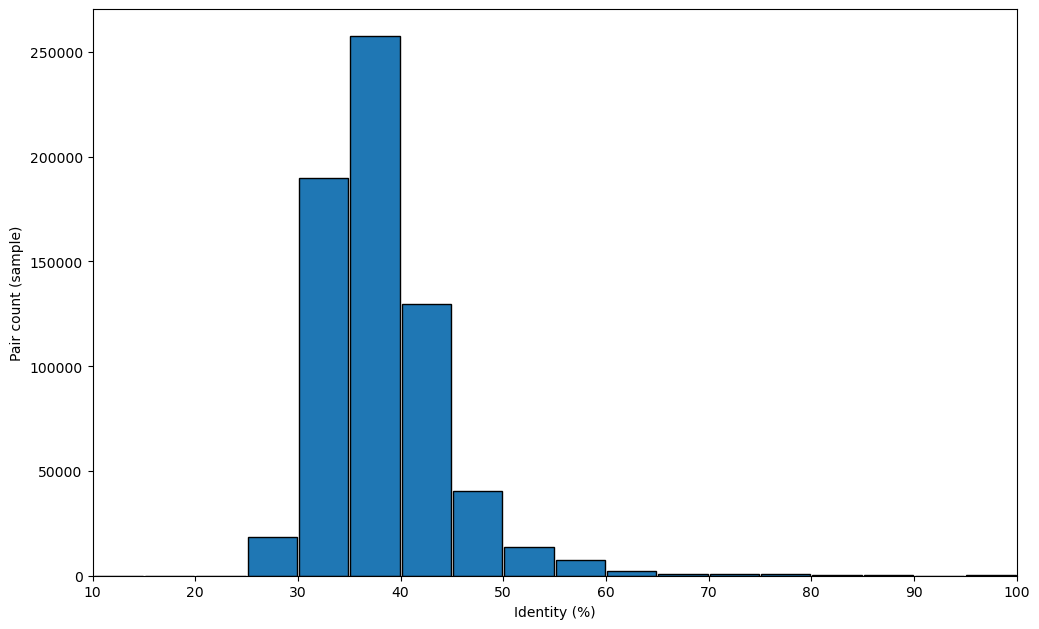

[saved] 01_bar_identity_10_100.svg 01_bar_identity_10_100.png 01_bar_identity_10_100.tiff


/home/mattoslmp/anaconda3/envs/fall/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/mattoslmp/anaconda3/envs/fall/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


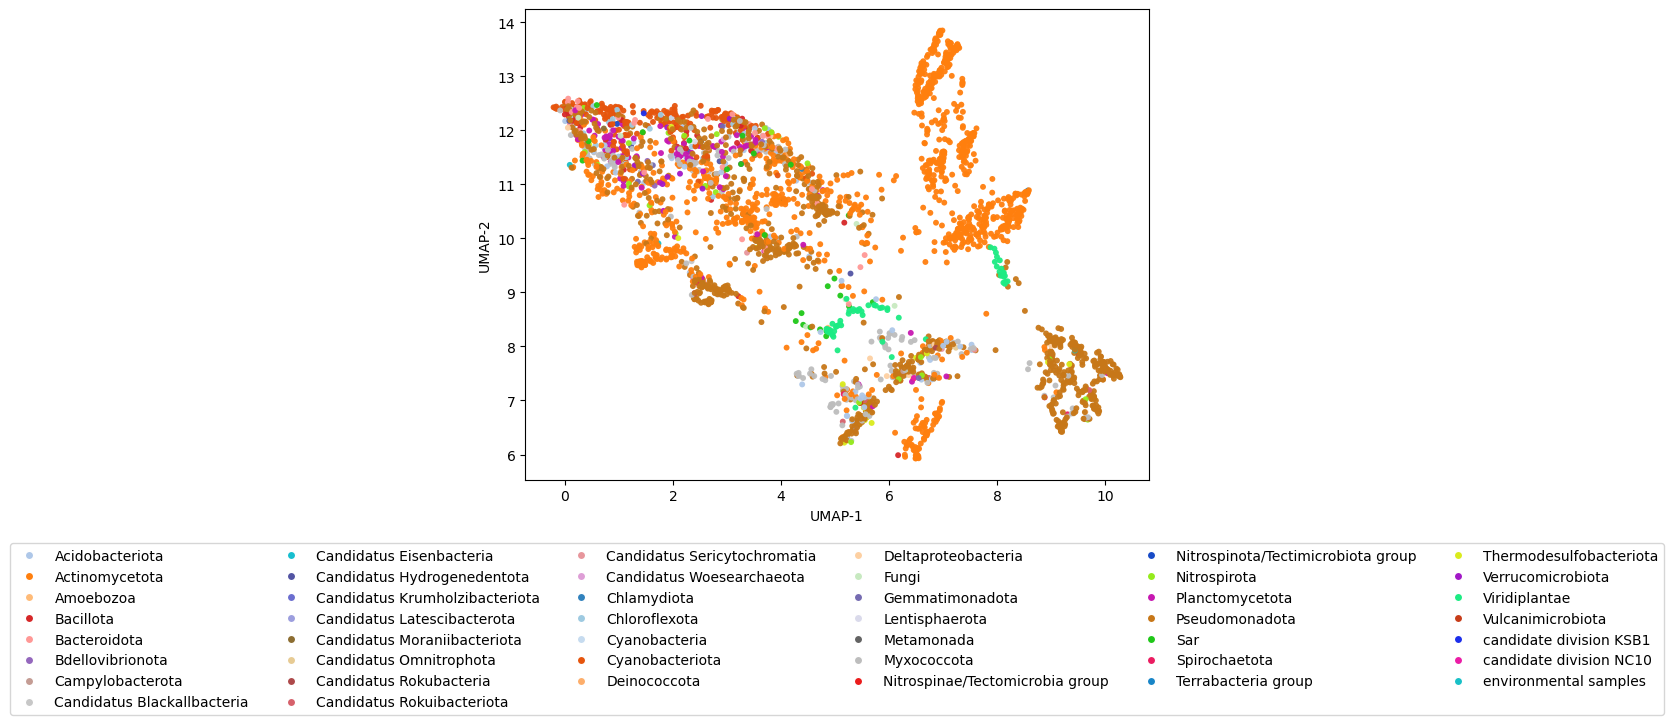

[saved] 04_umap_dissimilarity_by_phylum.svg 04_umap_dissimilarity_by_phylum.png 04_umap_dissimilarity_by_phylum.tiff


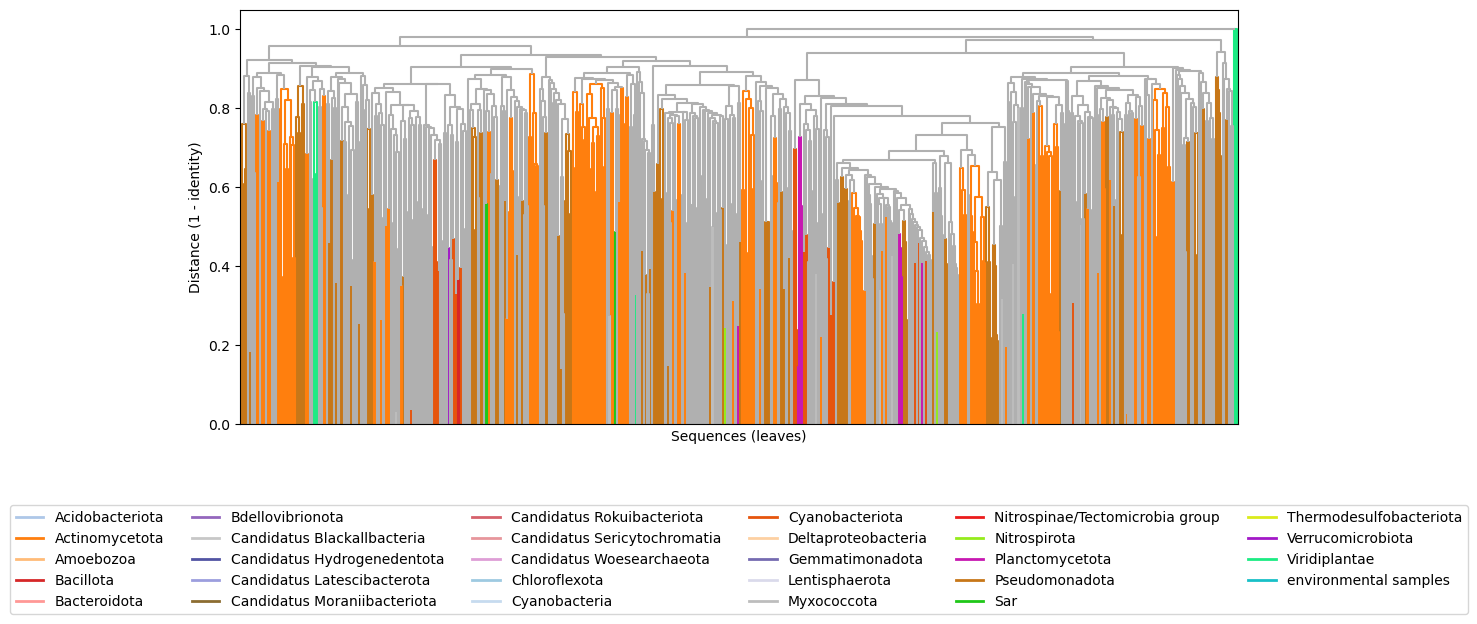

[saved] 03_dendrogram_branches_by_phylum.svg 03_dendrogram_branches_by_phylum.png 03_dendrogram_branches_by_phylum.tiff


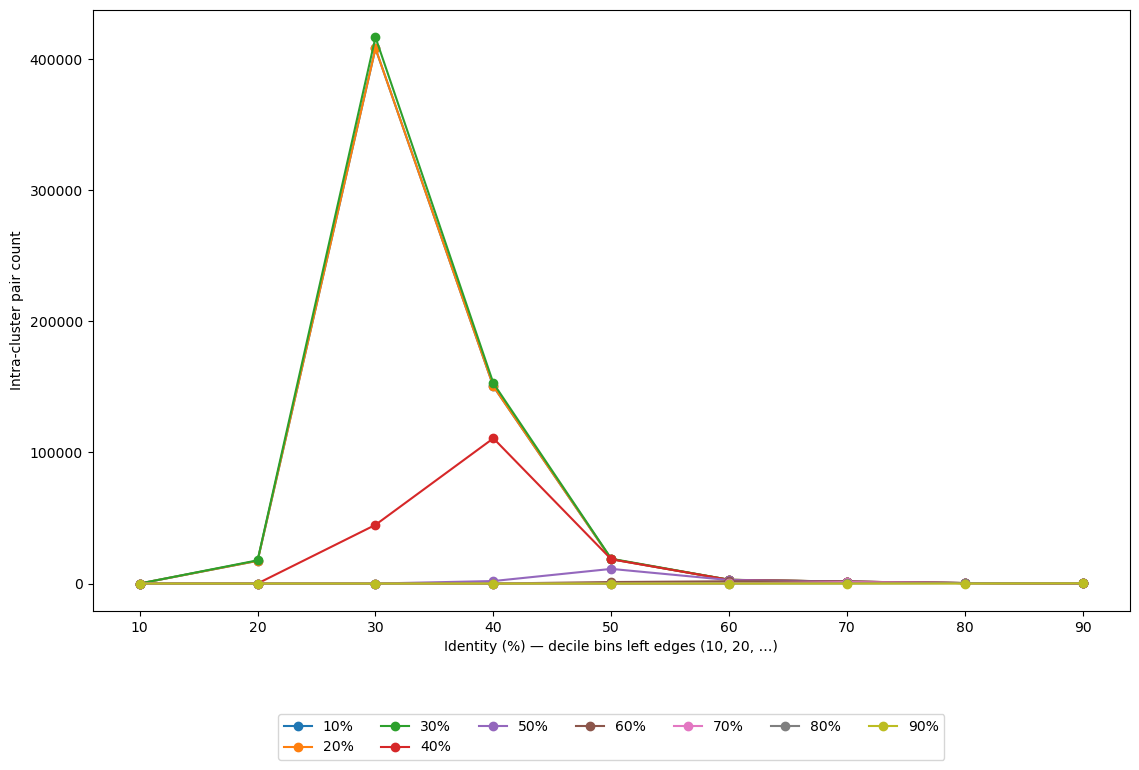

[saved] 06a_counts_intra_identity_bins_by_cutoff_lines_REALX.svg 06a_counts_intra_identity_bins_by_cutoff_lines_REALX.png 06a_counts_intra_identity_bins_by_cutoff_lines_REALX.tiff


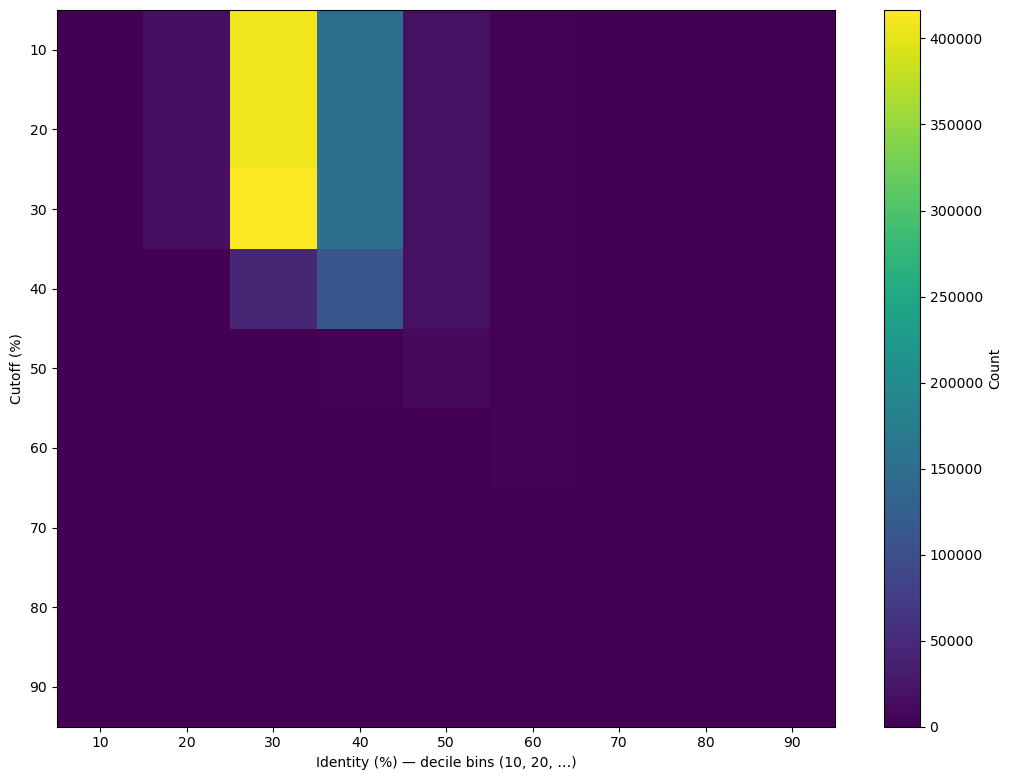

[saved] 06b_counts_intra_identity_bins_by_cutoff_heatmap.svg 06b_counts_intra_identity_bins_by_cutoff_heatmap.png 06b_counts_intra_identity_bins_by_cutoff_heatmap.tiff


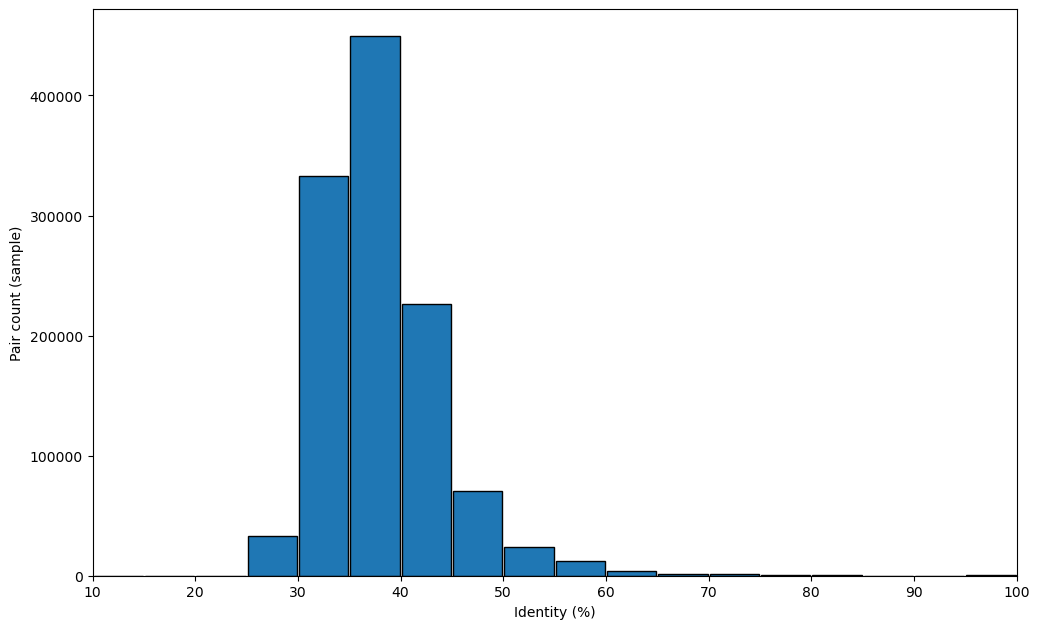

[saved] 01_bar_identity_10_100.svg 01_bar_identity_10_100.png 01_bar_identity_10_100.tiff


/home/mattoslmp/anaconda3/envs/fall/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/mattoslmp/anaconda3/envs/fall/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


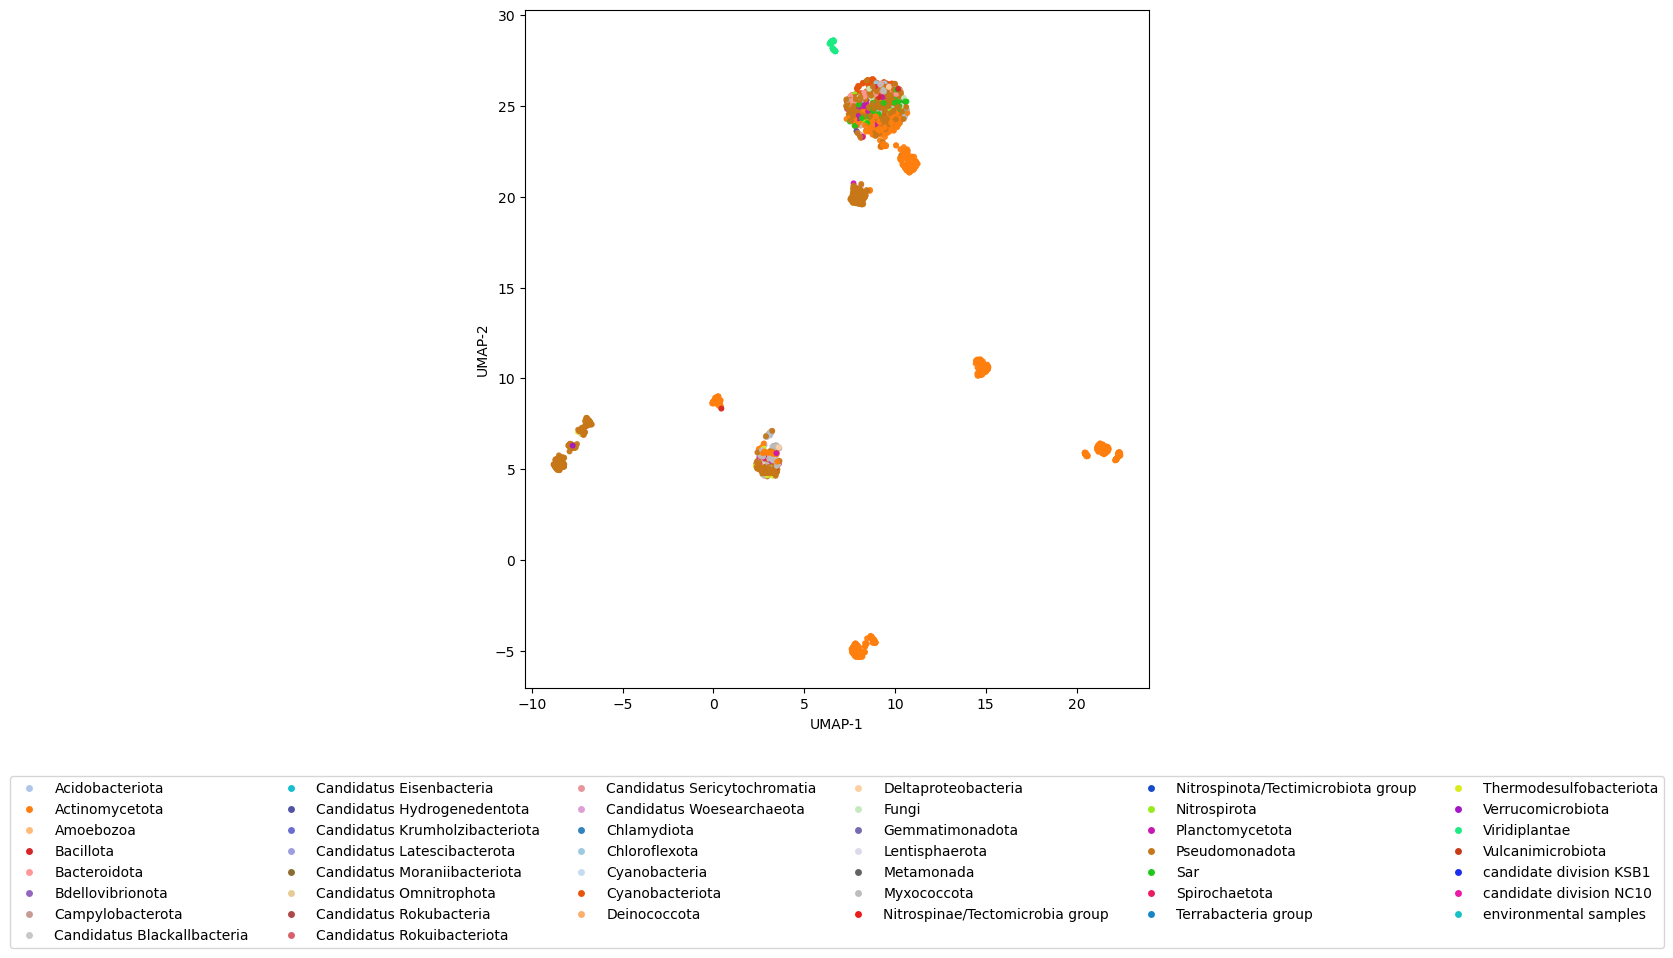

[saved] 04_umap_dissimilarity_by_phylum.svg 04_umap_dissimilarity_by_phylum.png 04_umap_dissimilarity_by_phylum.tiff


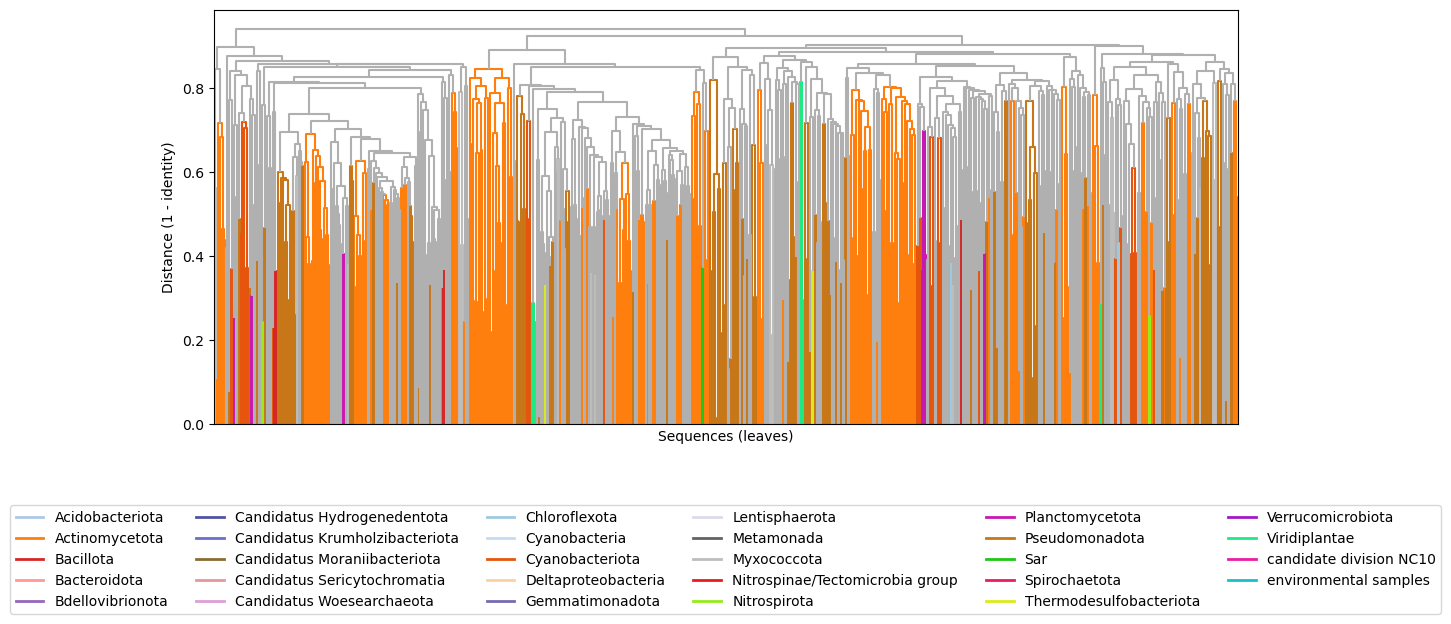

[saved] 03_dendrogram_branches_by_phylum.svg 03_dendrogram_branches_by_phylum.png 03_dendrogram_branches_by_phylum.tiff


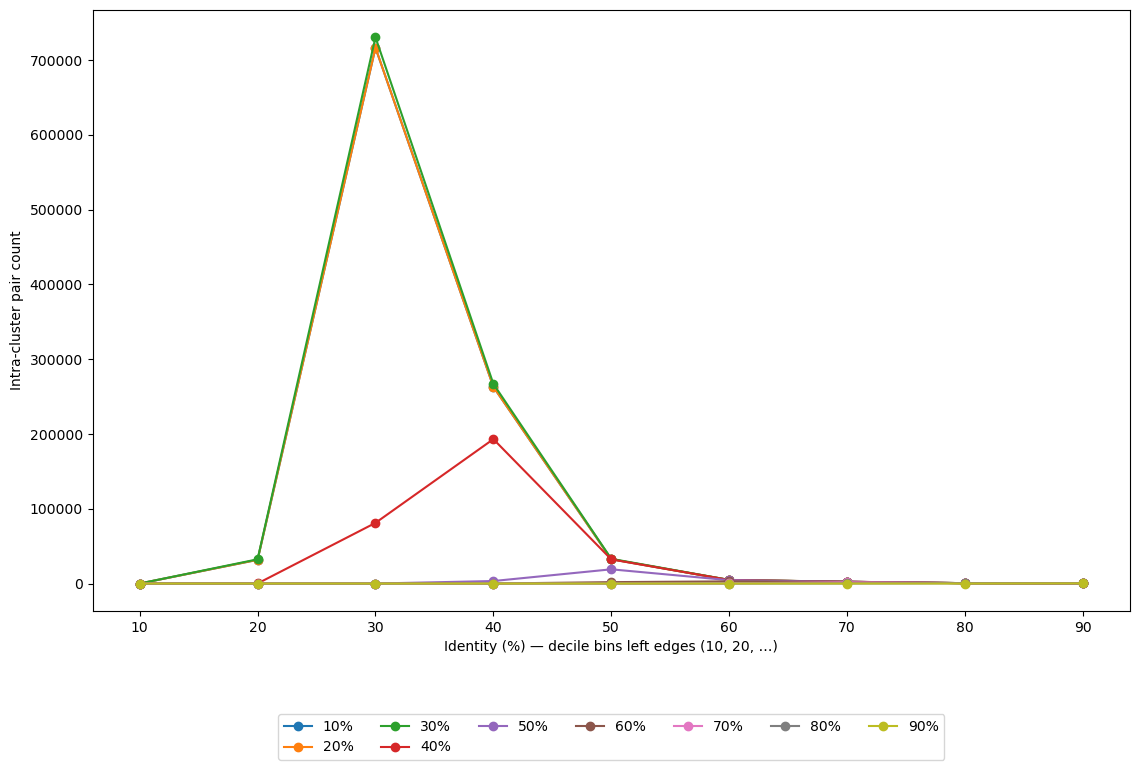

[saved] 06a_counts_intra_identity_bins_by_cutoff_lines_REALX.svg 06a_counts_intra_identity_bins_by_cutoff_lines_REALX.png 06a_counts_intra_identity_bins_by_cutoff_lines_REALX.tiff


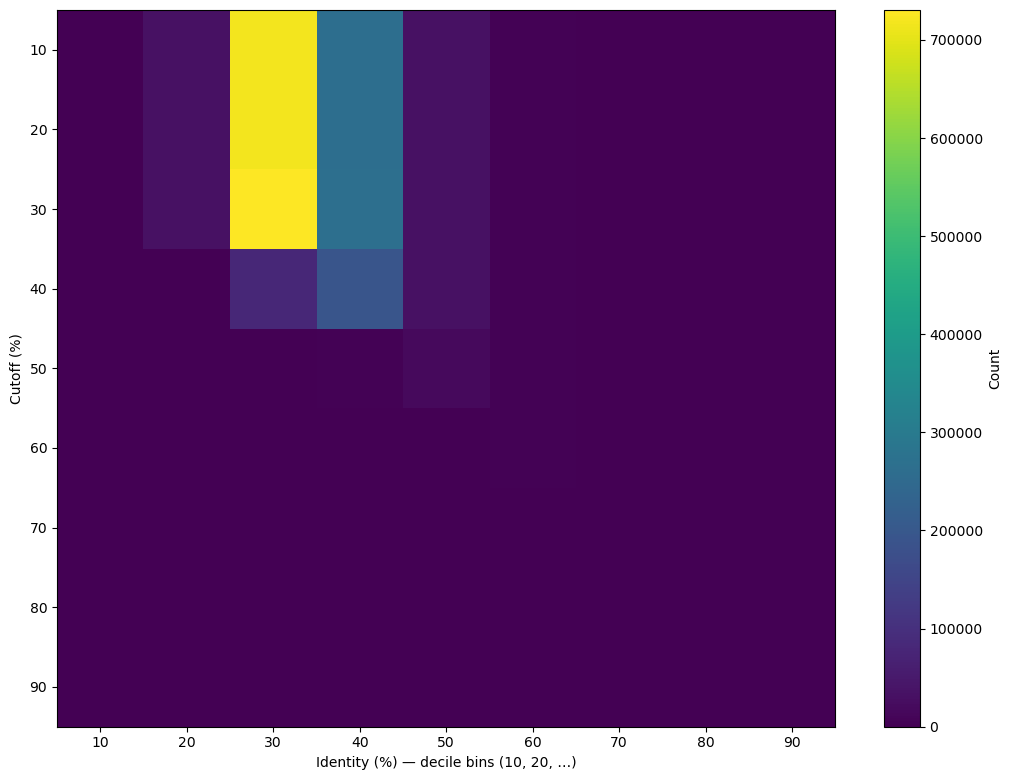

[saved] 06b_counts_intra_identity_bins_by_cutoff_heatmap.svg 06b_counts_intra_identity_bins_by_cutoff_heatmap.png 06b_counts_intra_identity_bins_by_cutoff_heatmap.tiff


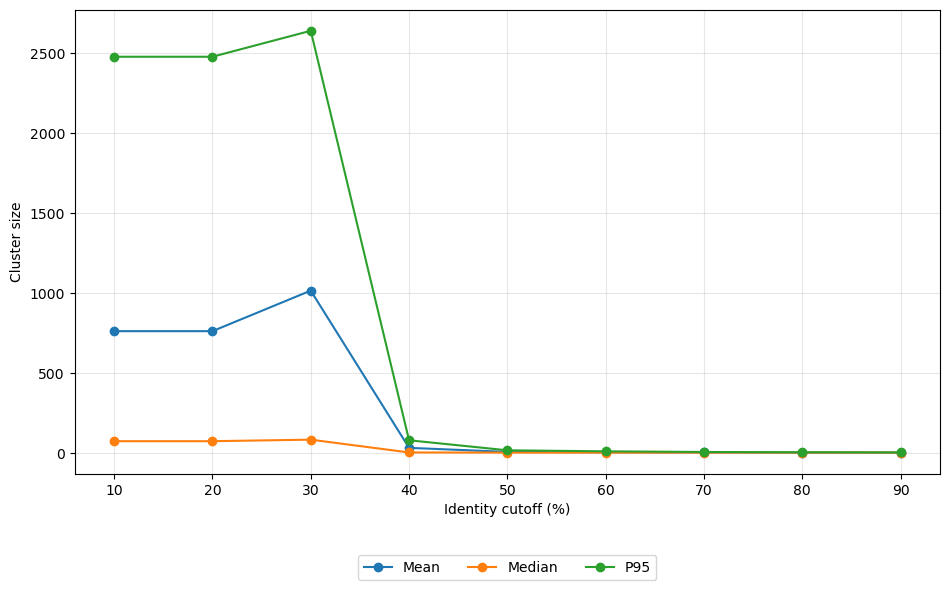

[saved] 04_cluster_size_vs_identity_cutoff.svg 04_cluster_size_vs_identity_cutoff.png 04_cluster_size_vs_identity_cutoff.tiff


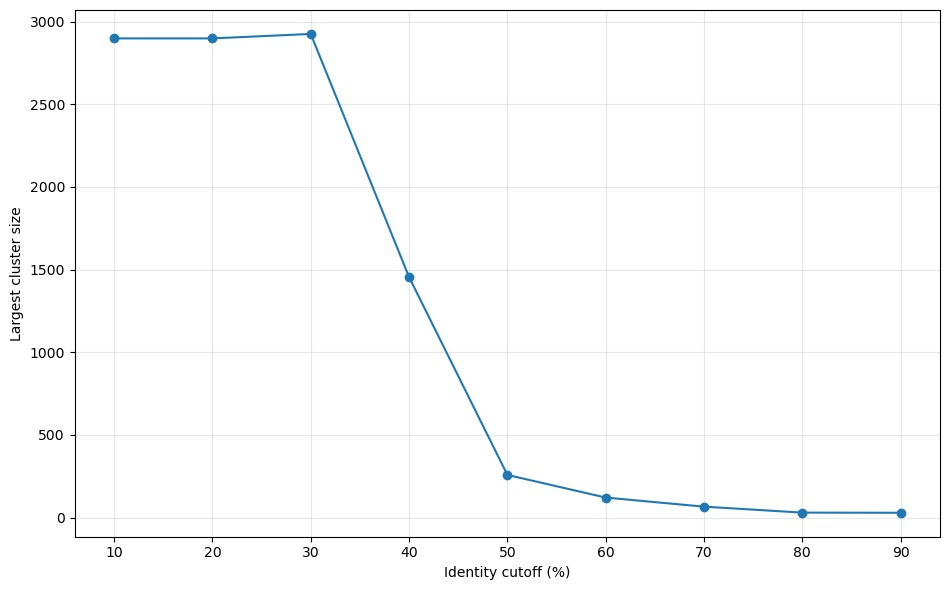

[saved] 05_largest_cluster_by_identity_cutoff.svg 05_largest_cluster_by_identity_cutoff.png 05_largest_cluster_by_identity_cutoff.tiff


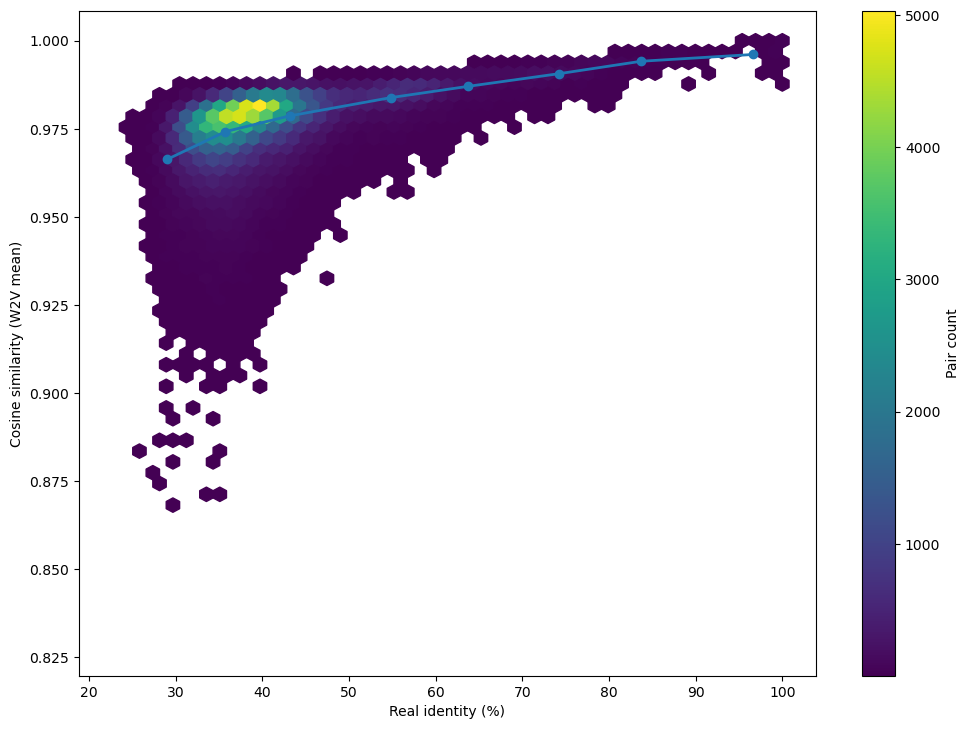

[saved] 07_cosine_vs_identity_intra.svg 07_cosine_vs_identity_intra.png 07_cosine_vs_identity_intra.tiff


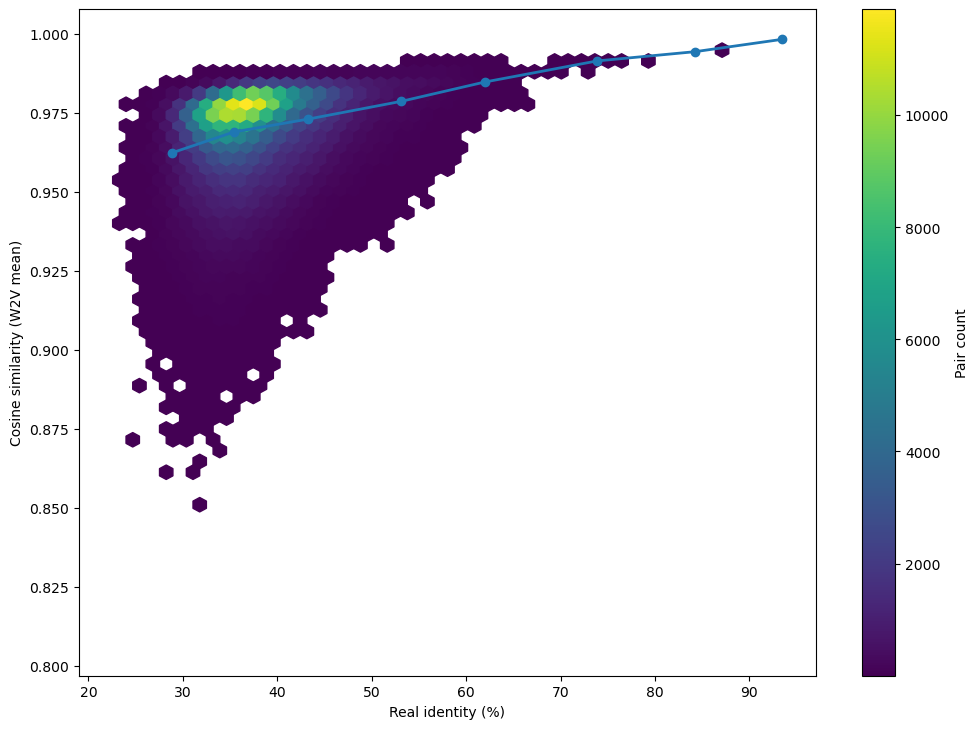

[saved] 08_cosine_vs_identity_inter.svg 08_cosine_vs_identity_inter.png 08_cosine_vs_identity_inter.tiff


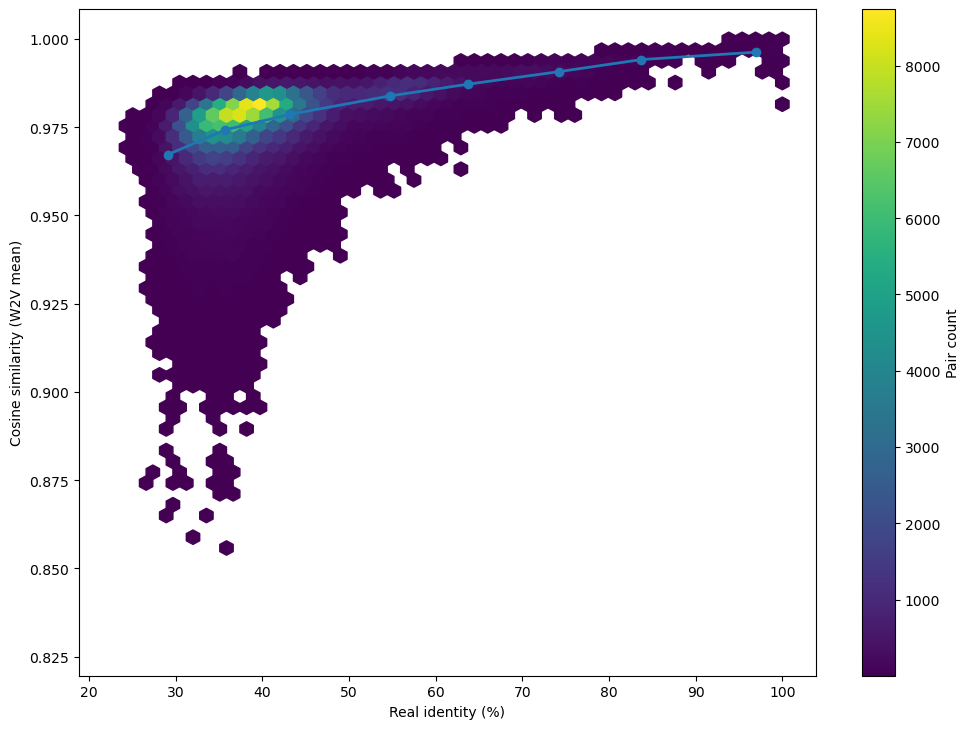

[saved] 07_cosine_vs_identity_intra.svg 07_cosine_vs_identity_intra.png 07_cosine_vs_identity_intra.tiff


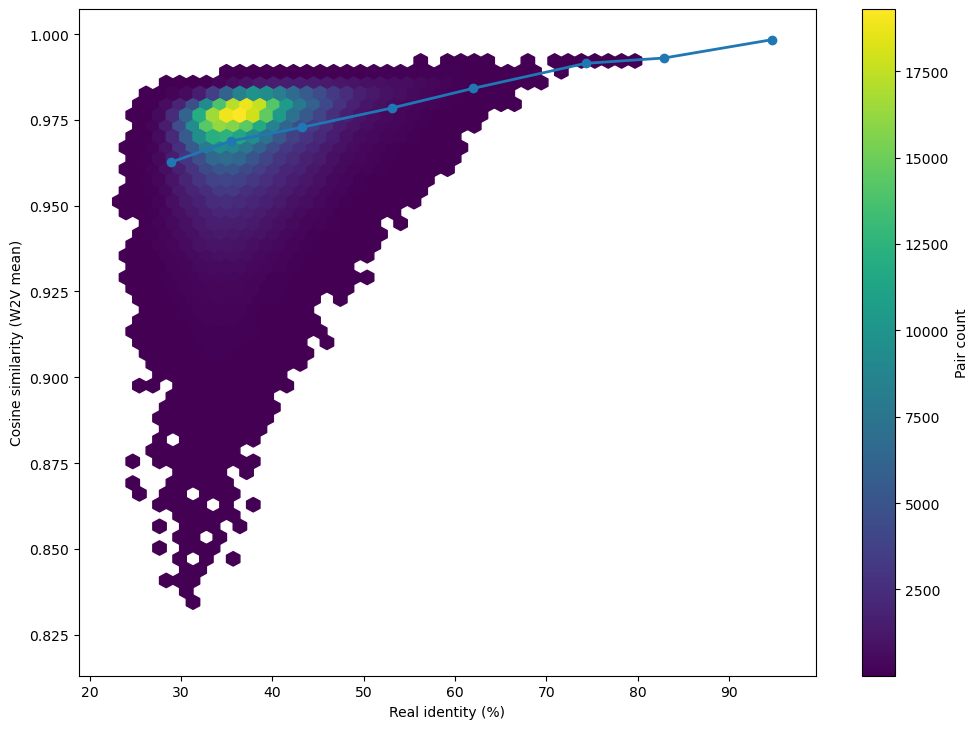

[saved] 08_cosine_vs_identity_inter.svg 08_cosine_vs_identity_inter.png 08_cosine_vs_identity_inter.tiff


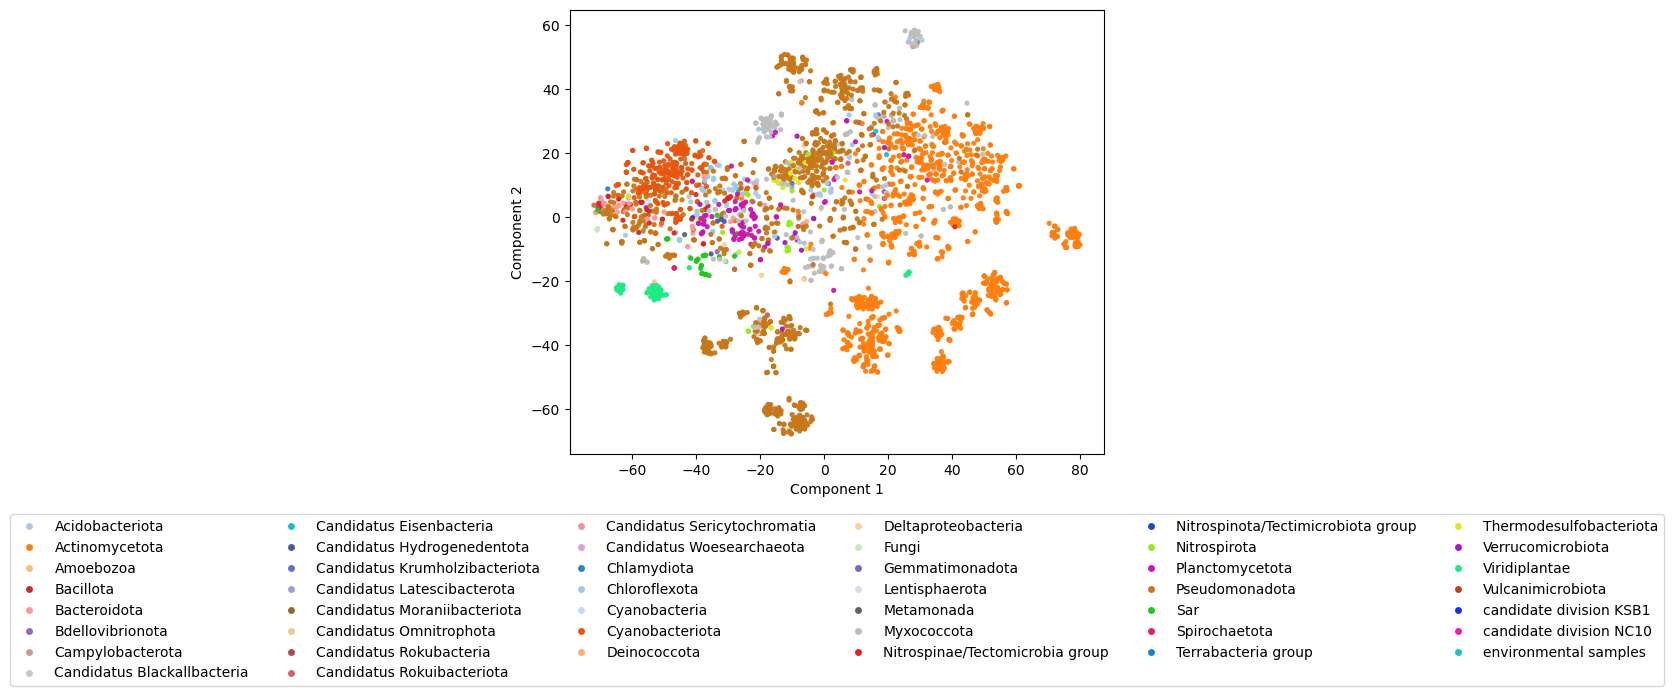

[saved] 09_tsne_w2v_mean_by_phylum.svg 09_tsne_w2v_mean_by_phylum.png 09_tsne_w2v_mean_by_phylum.tiff


/home/mattoslmp/anaconda3/envs/fall/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


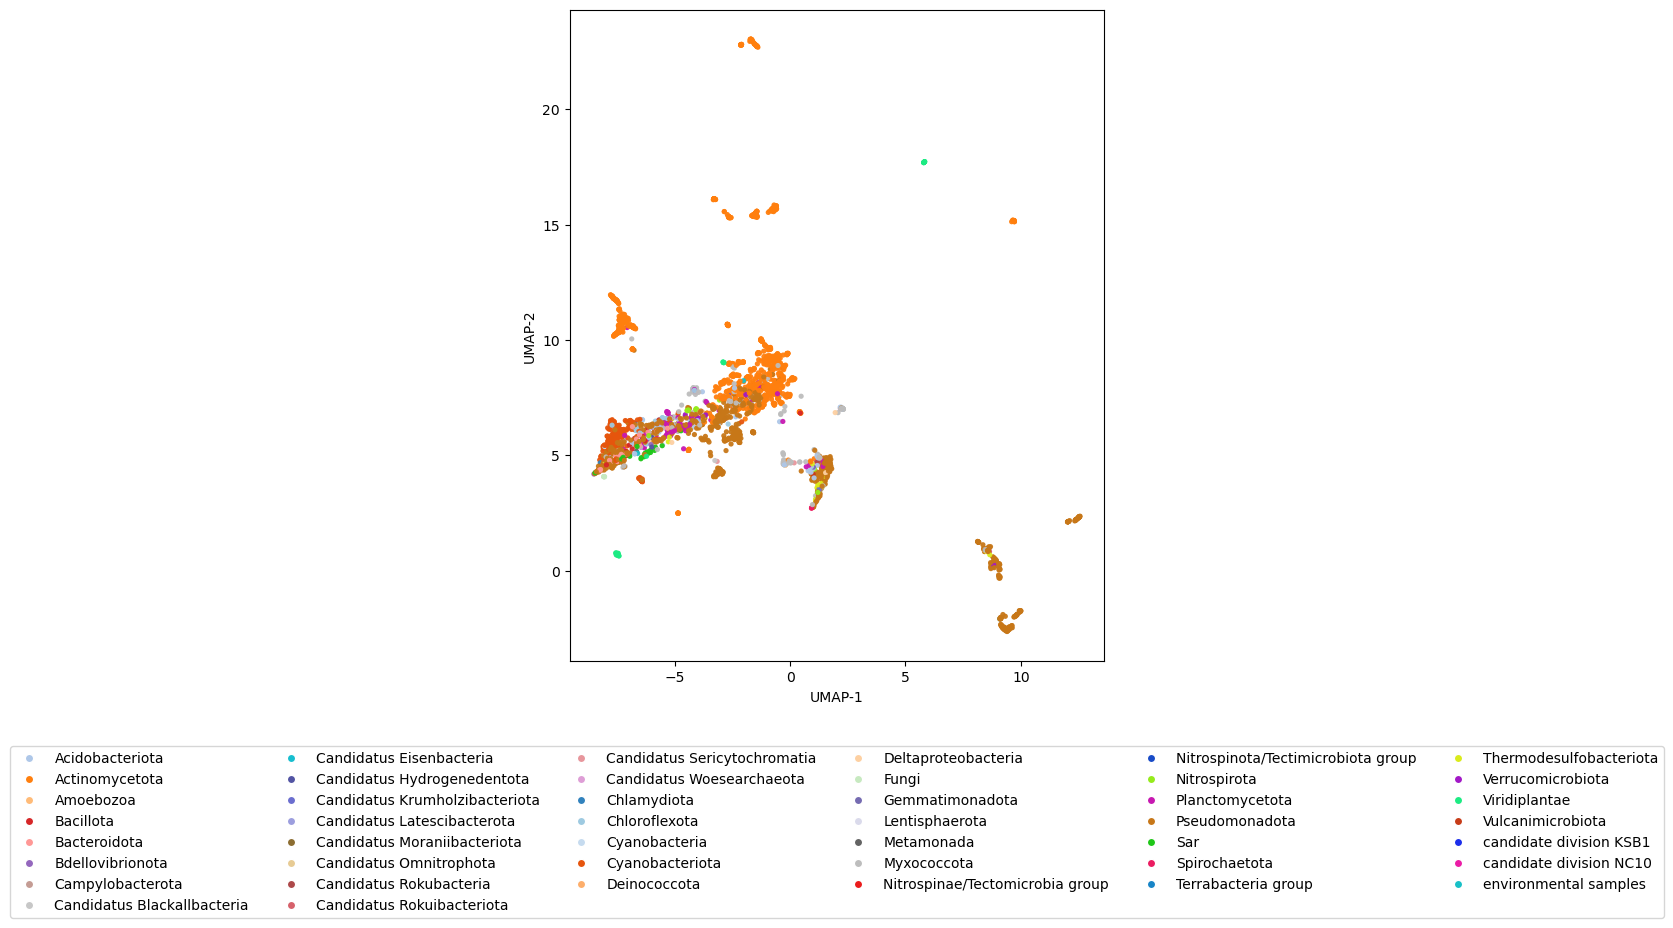

[saved] 10_umap_w2v_mean_by_phylum.svg 10_umap_w2v_mean_by_phylum.png 10_umap_w2v_mean_by_phylum.tiff


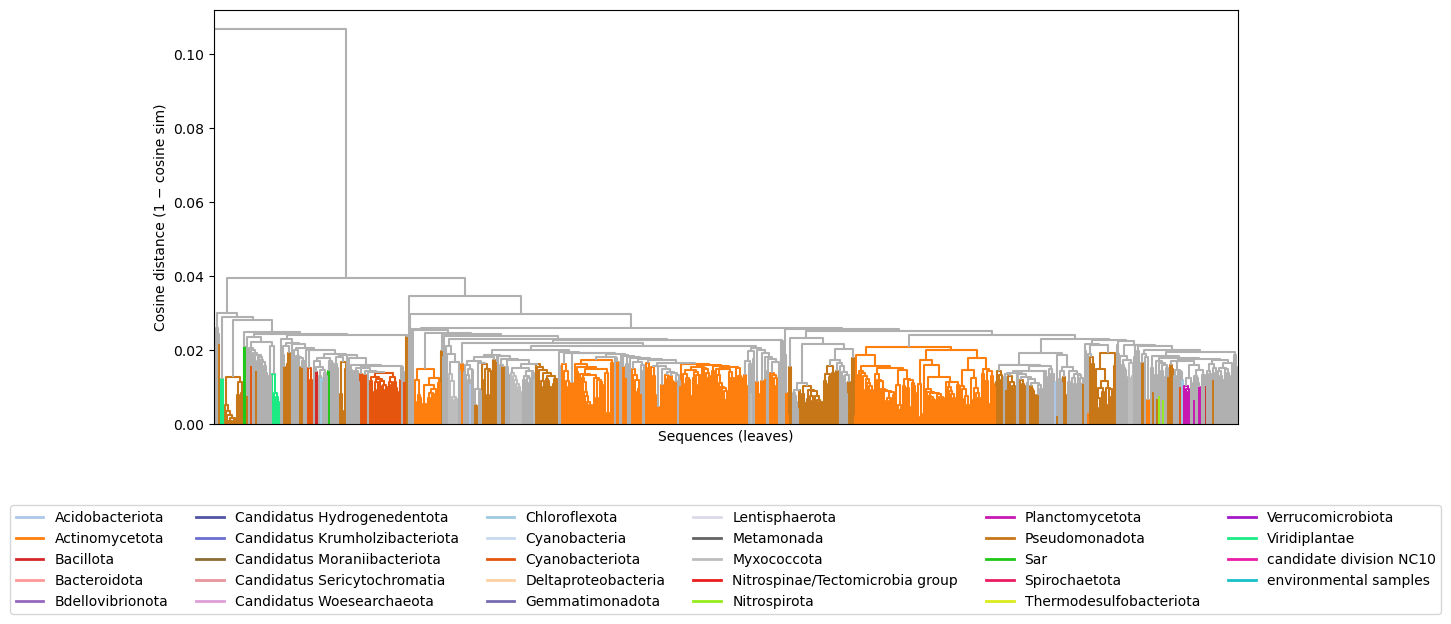

[saved] 13_dendrogram_w2v_mean_by_phylum.svg 13_dendrogram_w2v_mean_by_phylum.png 13_dendrogram_w2v_mean_by_phylum.tiff
[OK] Done. Outputs in: runs/FAALProt_Heterogeneity_v6/subset_frac_0p200
Run dir: runs/FAALProt_Heterogeneity_v6/subset_frac_0p200


In [15]:

# --- Configure & Run (uncomment to execute) ---
subset = SubsetParams(size=None, fraction=0.20, seed=42)
w2v_params = W2VParams(k=3, vector_size=200, window=5, min_count=1, sg=1, epochs=20, workers=4)

mafft_hint = '/usr/bin/mafft'  # adjust if needed
mmseqs_hint = '/home/mattoslmp/anaconda3/envs/fall/bin/mmseqs'  # adjust if needed

print('NOTE: To run, uncomment the call below.')
run_dir = run_pipeline('FAAL_NR_MIBIG_LEGE_FFT_NS_2_raw_data.fasta', 'runs/FAALProt_Heterogeneity_v6',
                       table_s2_path='Table_S2.tsv',
                       subset=subset, mafft_opts=['--auto'], mmseqs_extra_opts=['--cov-mode','0'],
                       sample_sizes=[600_000, 1_000_000], run_part_b=True, w2v_params=w2v_params,
                       mafft_bin=mafft_hint, mmseqs_bin=mmseqs_hint)
print('Run dir:', run_dir)
